<center><span style="font-family: TimesNewRoman; font-size:1.4em;color:blue;">
<b>LinearRegression: Predict Price for Used Car in Vietnam</b></span></center><br>

<center>
<img src="https://s.bonbanh.com/uploads/users/170848/salon/l_1665138439.jpg"
     width="400" height="300">
</center>

<p size=1 ><i></i></p><br>


## Context
    
<p style = "font-size : 15px ; color: black;font-family:TimesNewRoman">
Trong nhiều năm qua, nhu cầu mua bán và sử dụng xe hơi cũ rất lớn, rẻ hơn, được kiểm chứng, yên tâm về vận hành khiến người sử dụng ưu tiên xe cũ hơn là mua một chiếc xe mới hoàn toàn. Hơn nữa, với bối cảnh nhiều người lựa chọn xe điện hơn là xe hơi sử dụng nhiên liệu hóa thạch và với chính sách hạn chế xe hơi sử dụng nhiên liệu hóa thạch trong nội đô thành phố thì thị trường xe cũ càng được quan tâm hơn cho những người có nhu cầu cần một chiếc xe ổn trong tầm giá và đi ra ngoài ngoại ô. Không giống như xe mới hoàn toàn, giá cả và nhà cung cấp của xe mới được quản lý bởi OEMs (Original Equipment Manufacturer), xe cũ rất khác về giá cả và nhà cung cấp bởi mỗi chiếc xe cũ sẽ có một tình trạng đã qua sử dụng khác nhau nên mức giá sẽ không có một tiêu chuẩn nào để đánh giá. Đó cũng là tất cả lý do mà tôi cho ra đời mô hình dự đoán giá xe cũ để giúp bạn cũng như những người cần mua xe cũ có được cái giá hợp lý nhất.</p>

## Data Set
<br>
<p style = "font-size : 15px ; color: black;font-family:TimesNewRoman">
    
1. S.No. : STT<br>
    
2. Name : Tên xe bao gồm tên hãng và tên model<br>
    
3. Location : Vị trí xe đang được giao bán hoặc có sẵn<br>
    
4. Year : Năm sản xuất<br>
    
5. Kilometers_driven : Số KM xe đã đi được<br>
    
6. Fuel_Type : Loại nhiên liệu sử dụng (Petrol, Diesel, Electric, CNG, LPG)<br>
    
7. Transmission : Loại hộp số (Automatic / Manual)<br>
    
8. Owner : Xe đã qua bao nhiều đời chủ<br>
    
9. Mileage : Mức tiêu hao nhiên liệu (kmpl) theo công bố của hãng xe<br>
    
10. Engine : Dung tích xi lanh (CC)<br>
    
11. Power : Công suất cực đại<br>
    
12. Seats : Số ghế<br>
    
13. New_Price : Giá mua mới của chiếc xe<br>
    
14. Price : Giá mua khi xe đã qua sử dụng<br>
</p>

## Problem
<p style = "font-size : 15px ; color: black;font-family:TimesNewRoman">

- Liệu các yếu tố dự báo khác nhau có ảnh hưởng đến giá của xe đã qua sử dụng không ? <br>
- Những biến độc lập nào ảnh hưởng đến việc định giá xe đã qua sử dụng ?<br>
- Tên (mẫu) xe có ảnh hưởng đến giá bán không ?<br>
- Loại truyền động/hộp số ảnh hưởng đến giá như thế nào ?<br>
- Địa điểm nơi chiếc xe được bán có ảnh hưởng đến giá không ?<br>
- Số ki-lô-mét đã chạy và năm sản xuất có tương quan âm với giá xe không ?<br>
- Mức tiêu hao nhiên liệu (mileage), dung tích động cơ và công suất có ảnh hưởng đến giá xe không ?<br>
- Số chỗ ngồi và loại nhiên liệu ảnh hưởng đến giá như thế nào ?<br>
</p>

# Libraries


In [ ]:
### IMPORT: ------------------------------------
import scipy.stats as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # To supress warnings
 # set the background for the graphs
from scipy.stats import skew
plt.style.use('ggplot')
import missingno as msno # to get visualization on missing values
from sklearn.model_selection import train_test_split # Sklearn package's randomized data splitting function
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import math
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_colwidth',400)
pd.set_option('display.float_format', lambda x: '%.5f' % x) # To supress numerical display in scientific notations
import statsmodels.api as sm
print("Load Libraries- Done")

Load Libraries- Done


# Read and Understand data

In [ ]:
#Reading the csv file  used car data.csv
data_path='/used_cars_vietnam_divided.csv'
df=pd.read_csv(data_path,index_col=0)
cars=df.copy()
print(f'There are {cars.shape[0]} rows and {cars.shape[1]} columns') # fstring

There are 7253 rows and 13 columns


In [ ]:
# inspect data, print top 5
cars.head(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
S.No.,,,,,,,,,,,,,
0,Maruti Wagon R LXI CNG,Ha Noi,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.00000,NaN,45.00000
1,Hyundai Creta 1.6 CRDi SX Option,Lao Cai,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.00000,NaN,299.00000
2,Honda Jazz V,Ha Noi,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.00000,258.30000,122.00000
3,Maruti Ertiga VDI,Ha Noi,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.00000,NaN,147.00000
4,Audi A4 New 2.0 TDI Multitronic,Lang Son,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.00000,NaN,416.00000


In [ ]:
# bottom 5 rows:
cars.tail(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
S.No.,,,,,,,,,,,,,
7248,Volkswagen Vento Diesel Trendline,Ha Noi,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.00000,NaN,NaN
7249,Volkswagen Polo GT TSI,Ho Chi Minh,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.00000,NaN,NaN
7250,Nissan Micra Diesel XV,Khanh Hoa,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.00000,NaN,NaN
7251,Volkswagen Polo GT TSI,Hai Phong,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.00000,NaN,NaN
7252,Mercedes-Benz E-Class 2009-2013 E 220 CDI Avantgarde,Ho Chi Minh,2014,72443,Diesel,Automatic,First,10.0 kmpl,2148 CC,170 bhp,5.00000,NaN,NaN


In [ ]:
#get the size of dataframe
print ("Rows     : " , cars.shape[0])  #get number of rows/observations
print ("Columns  : " , cars.shape[1]) #get number of columns
print ("#"*40,"\n","Features : \n\n", cars.columns.tolist()) #get name of columns/features
print ("#"*40,"\nMissing values :\n\n", cars.isnull().sum().sort_values(ascending=False))
print( "#"*40,"\nPercent of missing :\n\n", round(cars.isna().sum() / cars.isna().count() * 100, 2)) # looking at columns with most Missing Values
print ("#"*40,"\nUnique values :  \n\n", cars.nunique())  #  count of unique values

Rows     :  7253
Columns  :  13
######################################## 
 Features : 

 ['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price']
######################################## 
Missing values :

 New_Price            6247
Price                1234
Seats                  53
Engine                 46
Power                  46
Mileage                 2
Fuel_Type               0
Year                    0
Location                0
Name                    0
Kilometers_Driven       0
Transmission            0
Owner_Type              0
dtype: int64
######################################## 
Percent of missing :

 Name                 0.00000
Location             0.00000
Year                 0.00000
Kilometers_Driven    0.00000
Fuel_Type            0.00000
Transmission         0.00000
Owner_Type           0.00000
Mileage              0.03000
Engine               0.63000
Power              

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               7253 non-null   object 
 1   Location           7253 non-null   object 
 2   Year               7253 non-null   int64  
 3   Kilometers_Driven  7253 non-null   int64  
 4   Fuel_Type          7253 non-null   object 
 5   Transmission       7253 non-null   object 
 6   Owner_Type         7253 non-null   object 
 7   Mileage            7251 non-null   object 
 8   Engine             7207 non-null   object 
 9   Power              7207 non-null   object 
 10  Seats              7200 non-null   float64
 11  New_Price          1006 non-null   float64
 12  Price              6019 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 793.3+ KB


<Axes: >

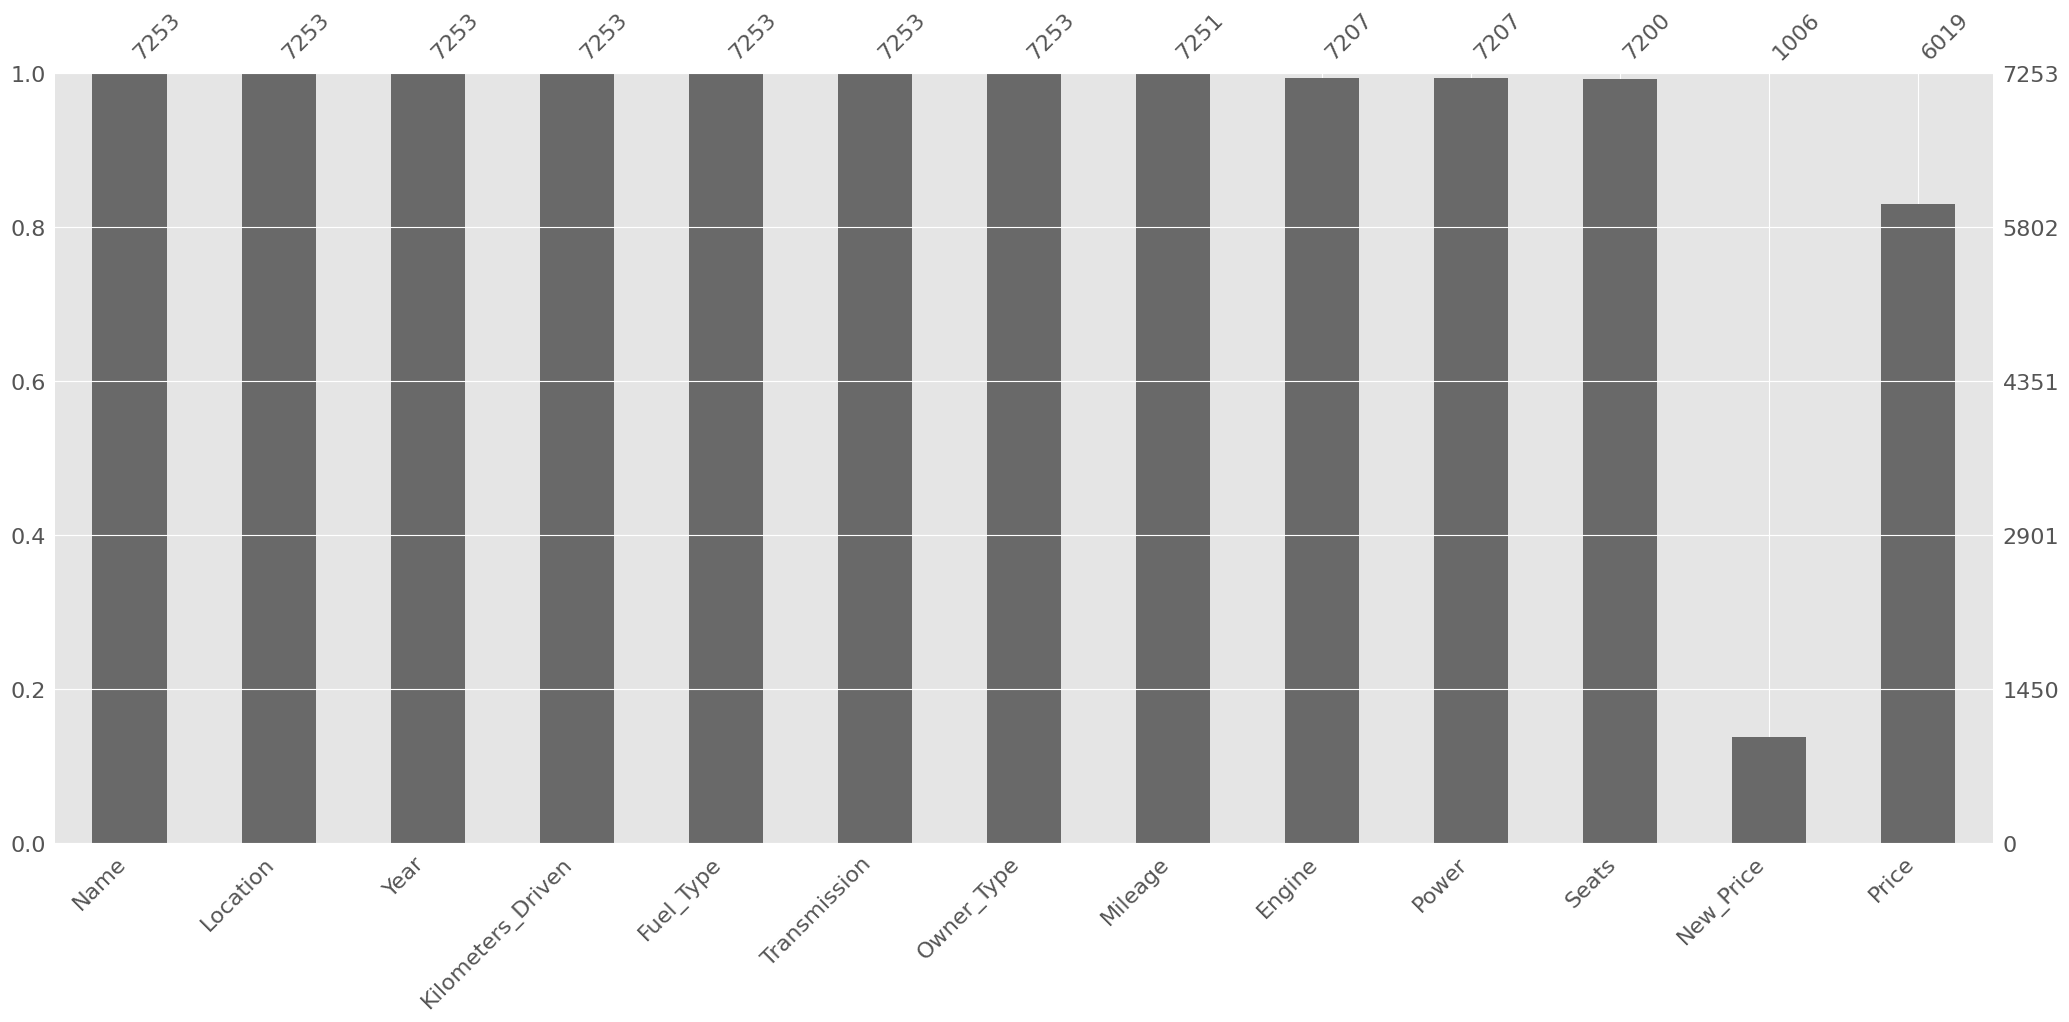

In [ ]:
#Visualize missing values
msno.bar(cars)


<p style = "font-size : 20px ; color: blue;font-family:TimesNewRoman">
<b>Observations</b></p>
Dễ thấy có vài cột đang chứa missing values, ta sẽ check xem đó là các cột nào.

-  **`New_Price`** có 1006 values. 86 % values đang bị khuyết

-  **`Price`**, cột Target có 17 % missing values. Ta sẽ phân tích cột này kĩ hơn

-  **`Seats`** có 53 missing values, ta cũng sẽ phân tích kĩ bởi số ghế cũng ảnh hưởng đến giá bán.
-  **`Power`** and **`Engine`** có 46 missing values.

-  **`Mileage`** có 2 missing values.

-  **`Mileage`,`Power`,`Engine`,`New_Price`** là các biến định lượng nhưng ở đây là kiểu object và cần phải chuyển đổi thành số.

In [ ]:
# Making a list of all categorical variables
cat_col = [
    "Fuel_Type",
    "Location",
    "Transmission",
    "Seats",
    "Year",
    "Owner_Type",

]
# Printing number of count of each unique value in each column
for column in cat_col:
    print(cars[column].value_counts())
    print("#" * 40)

Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: count, dtype: int64
########################################
Location
Ha Noi         2197
Ho Chi Minh    1097
Da Nang         440
Hai Phong       440
Lao Cai         220
Lang Son        220
Bac Ninh        220
Quang Ninh      220
Phu Tho         220
Thai Nguyen     220
Ninh Binh       220
Hung Yen        220
Nghe An         220
Thanh Hoa       220
Ha Tinh         220
Hue             220
Khanh Hoa       220
Can Tho         219
Name: count, dtype: int64
########################################
Transmission
Manual       5204
Automatic    2049
Name: count, dtype: int64
########################################
Seats
5.00000     6047
7.00000      796
8.00000      170
4.00000      119
6.00000       38
2.00000       18
10.00000       8
9.00000        3
0.00000        1
Name: count, dtype: int64
########################################
Year
2015    929
2014    925
2016    886
2013    791
2017   

<p style = "font-size : 20px ; color: blue;font-family:TimesNewRoman">
    <b>  Observations</b></p>

 - Đa số nhiên liệu được sử dụng là Diesel.
 - Ha Noi là địa phương có số xe được giao bán nhiều nhất.
 - 5204 xe sử dụng số sàn.
 - Đa số là xe 5 chỗ và qua 1 đời chủ.
 - Năm sản xuất trong khoảng từ 1996 - 2015.

# Data Preprocessing

### Processing Engine,Power ,Mileage columns

Datatype for Engine ,Power and Mileage  are object because of unit assigned ,so striping  units.

In [ ]:
#np.random.seed(9)
cars[['Engine','Power','Mileage']].sample(10)

,Engine,Power,Mileage
S.No.,,,
105,796 CC,35 bhp,14.0 kmpl
4108,2477 CC,175.56 bhp,13.5 kmpl
5846,1086 CC,62.1 bhp,17.92 kmpl
3299,2982 CC,168.5 bhp,12.55 kmpl
107,2993 CC,270.9 bhp,14.74 kmpl
3051,2987 CC,254.8 bhp,11.3 kmpl
4619,1461 CC,63.1 bhp,23.08 kmpl
6886,998 CC,67.04 bhp,22.5 kmpl
4191,1968 CC,174.33 bhp,15.73 kmpl


In [ ]:
typeoffuel=['CNG','LPG']
cars.loc[cars.Fuel_Type.isin(typeoffuel)].head(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
S.No.,,,,,,,,,,,,,
0,Maruti Wagon R LXI CNG,Ha Noi,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.00000,NaN,45.00000
5,Hyundai EON LPG Era Plus Option,Ha Noi,2012,75000,LPG,Manual,First,21.1 km/kg,814 CC,55.2 bhp,5.00000,NaN,59.00000
127,Maruti Wagon R LXI CNG,Ho Chi Minh,2013,89900,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.00000,NaN,79.00000
328,Maruti Zen Estilo LXI Green (CNG),Can Tho,2008,42496,CNG,Manual,First,26.3 km/kg,998 CC,67.1 bhp,5.00000,NaN,39.00000
440,Maruti Eeco 5 STR With AC Plus HTR CNG,Quang Ninh,2017,31841,CNG,Manual,First,15.1 km/kg,1196 CC,73 bhp,5.00000,NaN,110.00000
839,Maruti Alto Green LXi (CNG),Ninh Binh,2012,65537,CNG,Manual,First,26.83 km/kg,796 CC,38.4 bhp,5.00000,NaN,54.00000
893,Hyundai Accent Executive CNG,Ha Noi,2010,95637,CNG,Manual,Second,13.2 km/kg,1495 CC,93.7 bhp,5.00000,NaN,47.00000
936,Maruti Wagon R LXI LPG BSIV,Hai Phong,2012,72000,LPG,Manual,First,26.2 km/kg,998 CC,58.2 bhp,5.00000,NaN,70.00000
987,Maruti Wagon R LXI DUO BSIII,Ha Noi,2008,64226,LPG,Manual,First,17.3 km/kg,1061 CC,57.5 bhp,5.00000,NaN,40.00000


Cột Power có vài giá trị là "nullbhp" .Mileage cũng có vài giá trị là 0. Đối với loại nhiên liệu CNG và LPG, quãng đường đi được tính bằng km/kg, trong khi đối với các loại nhiên liệu khác, quãng đường đi được tính bằng km/l. Vì cả hai đơn vị đều tính bằng km nên không cần chuyển đổi. Đơn vị được tính từ quãng đường đi được, Động cơ và Công suất.

### Mileage

In [ ]:
cars[cars.Mileage.isnull()==True]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
S.No.,,,,,,,,,,,,,
4446,Mahindra E Verito D4,Hai Phong,2016,50000,Electric,Automatic,First,NaN,72 CC,41 bhp,5.00000,407.40000,292.00000
4904,Toyota Prius 2009-2016 Z4,Da Nang,2011,44000,Electric,Automatic,First,NaN,1798 CC,73 bhp,5.00000,NaN,353.00000


In [ ]:
cars["Mileage"] = cars["Mileage"].str.rstrip(" kmpl")
cars["Mileage"] = cars["Mileage"].str.rstrip(" km/g")


### Engine

In [ ]:
#remove units
cars["Engine"] = cars["Engine"].str.rstrip(" CC")


### Power

In [ ]:
#remove bhp and replace null with nan
cars["Power"] = cars["Power"].str.rstrip(" bhp")
cars["Power"]= cars["Power"].replace(regex="null", value = np.nan)


In [ ]:
#verify the data
num=['Engine','Power','Mileage']
cars[num].sample(20)

,Engine,Power,Mileage
S.No.,,,
217,1086,68.05,19.81
3690,1598,103.6,20.54
5115,1298,88.2,16.1
6940,1498,89.84,22.7
215,1796,186,11.74
4739,1248,88.5,24.52
2875,1498,98.6,25.8
6874,1405,70,19.1
2589,998,67,22.5


Xuất hiện vài values ở cột Power and Mileage là 0.0 nên ta cần check xem.

In [ ]:
cars.query("Power == '0.0'")['Power'].count()

np.int64(0)

In [ ]:
cars.query("Mileage == '0.0'")['Mileage'].count()


np.int64(81)

Tạm thời ta sẽ convert thành NaN sau đó sẽ xử lý missing values

In [ ]:
cars.loc[cars["Mileage"]=='0.0','Mileage']=np.nan

In [ ]:
cars.loc[cars["Engine"]=='0.0','Engine'].count()

np.int64(0)

In [ ]:
cars[num].nunique()

,0
Engine,150
Power,385
Mileage,437


In [ ]:
cars[num].isnull().sum()

,0
Engine,46
Power,175
Mileage,83


Có 46 missing values ở Engine, 175 ở  Power, 83 ở Mileage.

###  Processing Seats

In [ ]:
cars.query("Seats == 0.0")['Seats']

,Seats
S.No.,
3999,0.00000


In [ ]:
#seats cannot be 0 so changing it to nan and will be handled in missing value
cars.loc[3999,'Seats'] =np.nan


# Feature Enginering

## converting datatype

In [ ]:
#converting object data type to category data type
cars["Fuel_Type"] = cars["Fuel_Type"].astype("category")
cars["Transmission"] = cars["Transmission"].astype("category")
cars["Owner_Type"] = cars["Owner_Type"].astype("category")
#converting datatype
cars["Mileage"] = cars["Mileage"].astype(float)
cars["Power"] = cars["Power"].astype(float)
cars["Engine"]=cars["Engine"].astype(float)

In [ ]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,7253.00000,2013.36537,3.25442,1996.00000,2011.00000,2014.00000,2016.00000,2019.00000
Kilometers_Driven,7253.00000,58699.06315,84427.72058,171.00000,34000.00000,53416.00000,73000.00000,6500000.00000
Mileage,7170.00000,18.34653,4.15791,6.40000,15.30000,18.20000,21.10000,33.54000
Engine,7207.00000,1616.57347,595.28514,72.00000,1198.00000,1493.00000,1968.00000,5998.00000
Power,7078.00000,112.76521,53.49355,34.20000,75.00000,94.00000,138.10000,616.00000
Seats,7199.00000,5.28046,0.80933,2.00000,5.00000,5.00000,5.00000,10.00000
New_Price,1006.00000,683.39076,832.78031,117.30000,236.55000,347.10000,781.27500,11250.00000
Price,6019.00000,215.57269,235.95310,11.00000,86.00000,134.00000,234.00000,3439.00000


### Processing Years to Derive Age of car
Vì năm có 2014, 1996, v.v. Nhưng điều này sẽ không giúp hiểu được xe cũ như thế nào và ảnh hưởng của nó đến giá.
Vì vậy, hãy tạo hai cột mới là Current_year và Ageofcar. Năm hiện tại sẽ là 2025 và cột Ageofcar sẽ là Ageofcar = Current_year - Year. Sau đó, xóa các cột năm hiện tại.

In [ ]:
cars['Current_year']=2025
cars['Ageofcar']=cars['Current_year']-cars['Year']
cars.drop('Current_year',axis=1,inplace=True)
cars.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar
S.No.,,,,,,,,,,,,,,
0,Maruti Wagon R LXI CNG,Ha Noi,2010,72000,CNG,Manual,First,26.60000,998.00000,58.16000,5.00000,NaN,45.00000,15
1,Hyundai Creta 1.6 CRDi SX Option,Lao Cai,2015,41000,Diesel,Manual,First,19.67000,1582.00000,126.20000,5.00000,NaN,299.00000,10
2,Honda Jazz V,Ha Noi,2011,46000,Petrol,Manual,First,18.20000,1199.00000,88.70000,5.00000,258.30000,122.00000,14
3,Maruti Ertiga VDI,Ha Noi,2012,87000,Diesel,Manual,First,20.77000,1248.00000,88.76000,7.00000,NaN,147.00000,13
4,Audi A4 New 2.0 TDI Multitronic,Lang Son,2013,40670,Diesel,Automatic,Second,15.20000,1968.00000,140.80000,5.00000,NaN,416.00000,12


### Processing Name column

Extract tên hãng từ tên xe.

In [ ]:
#dropping rows with name as null
cars= cars.dropna(subset=['Name'])

In [ ]:
#As mentioned in dataset car name has Brand and model so extracting it ,This can help to fill missing values of price column as brand
cars['Brand'] = cars['Name'].str.split(' ').str[0] #Separating Brand name from the Name
cars['Model'] = cars['Name'].str.split(' ').str[1] + cars['Name'].str.split(' ').str[2]

In [ ]:
cars.Brand.unique()

array(['Maruti', 'Hyundai', 'Honda', 'Audi', 'Nissan', 'Toyota',
       'Volkswagen', 'Tata', 'Land', 'Mitsubishi', 'Renault',
       'Mercedes-Benz', 'BMW', 'Mahindra', 'Ford', 'Porsche', 'Datsun',
       'Jaguar', 'Volvo', 'Chevrolet', 'Skoda', 'Mini', 'Fiat', 'Jeep',
       'Smart', 'Ambassador', 'Isuzu', 'ISUZU', 'Force', 'Bentley',
       'Lamborghini', 'Hindustan', 'OpelCorsa'], dtype=object)

In [ ]:
col=['ISUZU','Isuzu','Mini','Land']
#correcting brand names
cars[cars.Brand.isin(col)].sample(5)


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar,Brand,Model
S.No.,,,,,,,,,,,,,,,,
5518,Mini Cooper 3 DOOR S,Ha Noi,2016,21110,Petrol,Automatic,First,17.44000,1998.00000,189.08000,4.00000,1178.10000,650.00000,9,Mini,Cooper3
6482,Mini Cooper 3 DOOR D,Ninh Binh,2017,26002,Diesel,Automatic,First,20.70000,1496.00000,113.98000,4.00000,1095.00000,NaN,8,Mini,Cooper3
6857,Land Rover Freelander 2 TD4 SE,Ho Chi Minh,2011,87000,Diesel,Automatic,First,NaN,2179.00000,115.00000,5.00000,NaN,NaN,14,Land,RoverFreelander
13,Land Rover Range Rover 2.2L Pure,Hung Yen,2014,72000,Diesel,Automatic,First,12.70000,2179.00000,187.70000,5.00000,NaN,555.00000,11,Land,RoverRange
4701,Land Rover Freelander 2 SE,Thanh Hoa,2014,85000,Diesel,Automatic,Second,12.39000,2179.00000,147.51000,5.00000,NaN,473.00000,11,Land,RoverFreelander


Tên hãng như ISUZU và Isuzu là một nên cần sửa lại. Land, Mini cũng vậy.

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7253 entries, 0 to 7252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Name               7253 non-null   object  
 1   Location           7253 non-null   object  
 2   Year               7253 non-null   int64   
 3   Kilometers_Driven  7253 non-null   int64   
 4   Fuel_Type          7253 non-null   category
 5   Transmission       7253 non-null   category
 6   Owner_Type         7253 non-null   category
 7   Mileage            7170 non-null   float64 
 8   Engine             7207 non-null   float64 
 9   Power              7078 non-null   float64 
 10  Seats              7199 non-null   float64 
 11  New_Price          1006 non-null   float64 
 12  Price              6019 non-null   float64 
 13  Ageofcar           7253 non-null   int64   
 14  Brand              7253 non-null   object  
 15  Model              7252 non-null   object  
dtypes: category

In [ ]:
#changing brandnames
cars.loc[cars.Brand == 'ISUZU','Brand']='Isuzu'
cars.loc[cars.Brand=='Mini','Brand']='Mini Cooper'
cars.loc[cars.Brand=='Land','Brand']='Land Rover'
#cars['Brand']=cars["Brand"].astype("category")

In [ ]:
cars.Brand.nunique()

32

In [ ]:
cars.groupby(cars.Brand).size().sort_values(ascending =False)

,0
Brand,
Maruti,1444
Hyundai,1340
Honda,743
Toyota,507
Mercedes-Benz,380
Volkswagen,374
Ford,351
Mahindra,331
BMW,312


Có 32 unique Brands trong dataset.Maruti là hãng được giao bán nhiểu nhất, followed theo sau là Huyndai.

In [ ]:
cars.Model.isnull().sum()

np.int64(1)

In [ ]:
#drop row with no model
cars.dropna(subset=['Model'],axis=0,inplace=True)

In [ ]:
cars.Model.nunique()

726

In [ ]:
cars.groupby('Model')['Model'].size().nlargest(30)

,Model
Model,
SwiftDzire,189
Grandi10,179
WagonR,178
Innova2.5,145
Verna1.6,127
City1.5,122
Cityi,115
Creta1.6,110
NewC-Class,110


Có 726 unique models và Swift Dzire là model chiếm đa số.

# EDA


In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7252 entries, 0 to 7252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Name               7252 non-null   object  
 1   Location           7252 non-null   object  
 2   Year               7252 non-null   int64   
 3   Kilometers_Driven  7252 non-null   int64   
 4   Fuel_Type          7252 non-null   category
 5   Transmission       7252 non-null   category
 6   Owner_Type         7252 non-null   category
 7   Mileage            7169 non-null   float64 
 8   Engine             7206 non-null   float64 
 9   Power              7077 non-null   float64 
 10  Seats              7198 non-null   float64 
 11  New_Price          1006 non-null   float64 
 12  Price              6019 non-null   float64 
 13  Ageofcar           7252 non-null   int64   
 14  Brand              7252 non-null   object  
 15  Model              7252 non-null   object  
dtypes: category

In [ ]:
cars.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar
count,7252.00000,7252.00000,7169.00000,7206.00000,7077.00000,7198.00000,1006.00000,6019.00000,7252.00000
mean,2013.36652,58700.26269,18.34711,1616.60505,112.76871,5.28049,683.39076,215.57269,11.63348
std,3.25316,84433.48037,4.15791,595.32041,53.49652,0.80938,832.78031,235.95310,3.25316
min,1996.00000,171.00000,6.40000,72.00000,34.20000,2.00000,117.30000,11.00000,6.00000
25%,2011.00000,34000.00000,15.30000,1198.00000,75.00000,5.00000,236.55000,86.00000,9.00000
50%,2014.00000,53429.00000,18.20000,1493.00000,94.00000,5.00000,347.10000,134.00000,11.00000
75%,2016.00000,73000.00000,21.10000,1968.00000,138.10000,5.00000,781.27500,234.00000,14.00000
max,2019.00000,6500000.00000,33.54000,5998.00000,616.00000,10.00000,11250.00000,3439.00000,29.00000


<p style = "font-size : 20px ; color: blue;font-family:TimesNewRoman"><b>Observations</b></p>

    
Years bị lệch trái (skew âm). Khoảng năm từ 1996–2019. Tuổi xe từ 6 đến 29 năm.

Kilometers driven: trung vị khoảng 53k km, trung bình khoảng 58k km. Giá trị tối đa khoảng 6,500,000 km — rất cao, có vẻ là ngoại lệ; cần phân tích thêm.

Mileage gần như phân phối chuẩn.

Engine lệch phải và có ngoại lệ ở cả phía thấp lẫn phía cao.

Power và Price cũng lệch phải.

Price = 4,800,000,000 là quá cao đối với xe đã qua sử dụng — có vẻ là ngoại lệ.

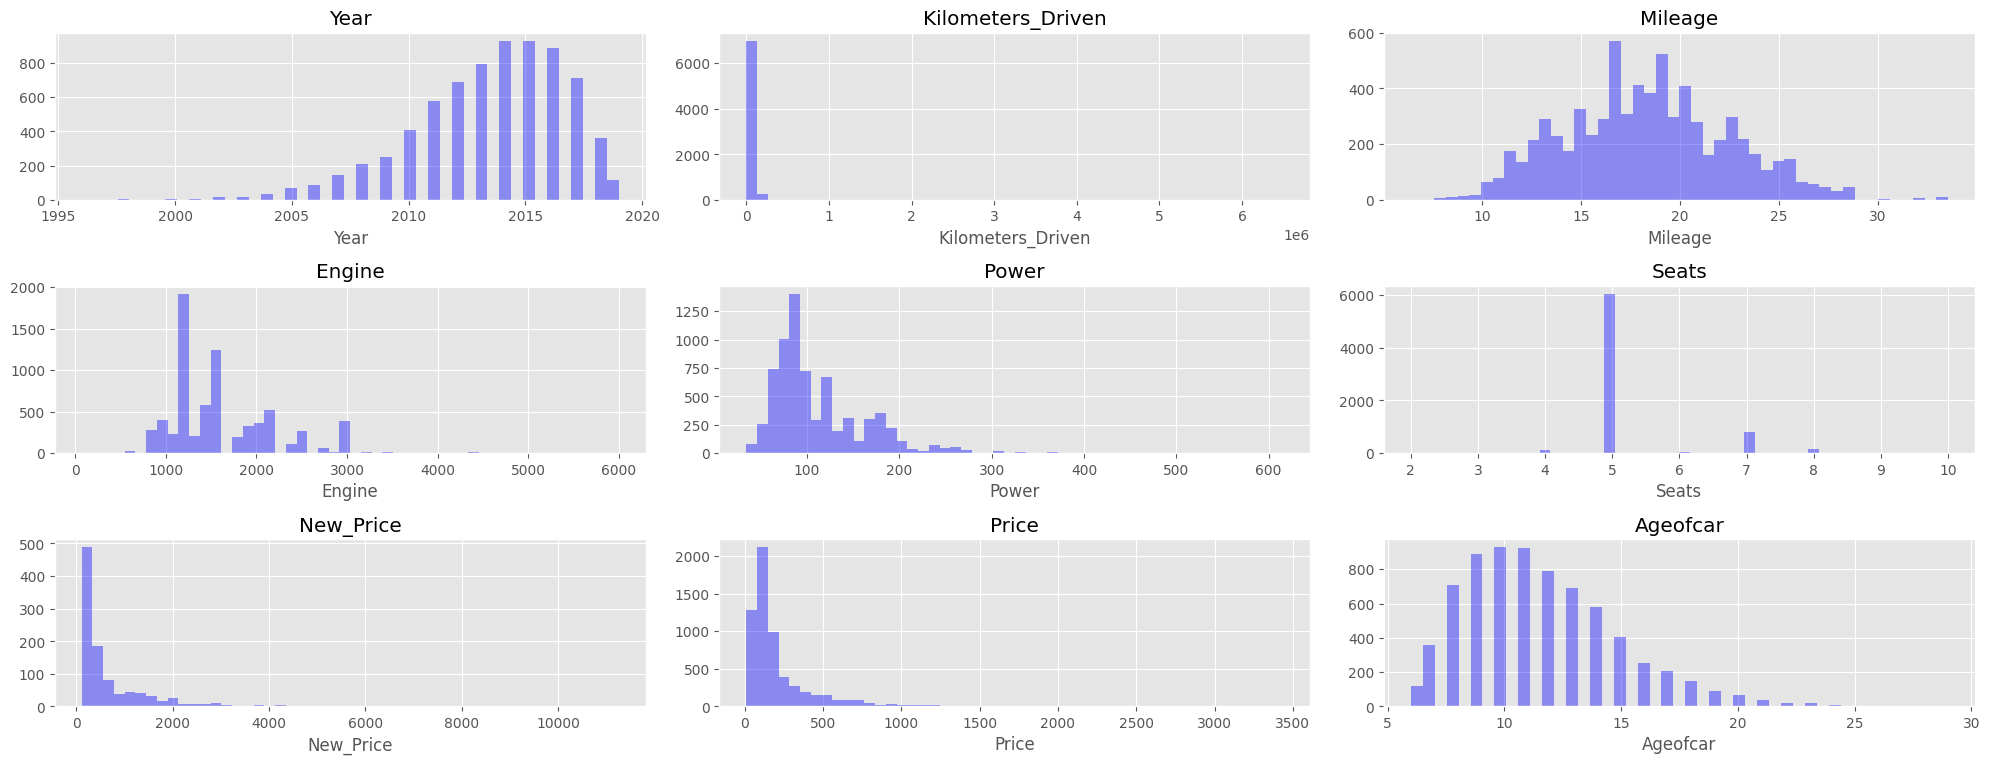

In [ ]:
plt.style.use('ggplot')
#select all quantitative columns for checking the spread
numeric_columns = cars.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(20,25))

for i, variable in enumerate(numeric_columns):
                     plt.subplot(10,3,i+1)

                     sns.distplot(cars[variable],kde=False,color='blue')
                     plt.tight_layout()
                     plt.title(variable)

<p style = "font-size : 15px ; color: blue;font-family:TimesNewRoman">
    <b>Observations</b></p>
    
  
Year bị lệch trái và có ngoại lệ ở phía giá trị thấp. Có thể loại cột này.

Kilometer_driven lệch phải.

Mileage gần như phân phối chuẩn; có một vài ngoại lệ ở cả phía cao và thấp — cần kiểm tra thêm.

Engine, power và price đều lệch phải và có ngoại lệ ở phía giá trị cao.

Tuổi xe (Age of car) lệch phải.


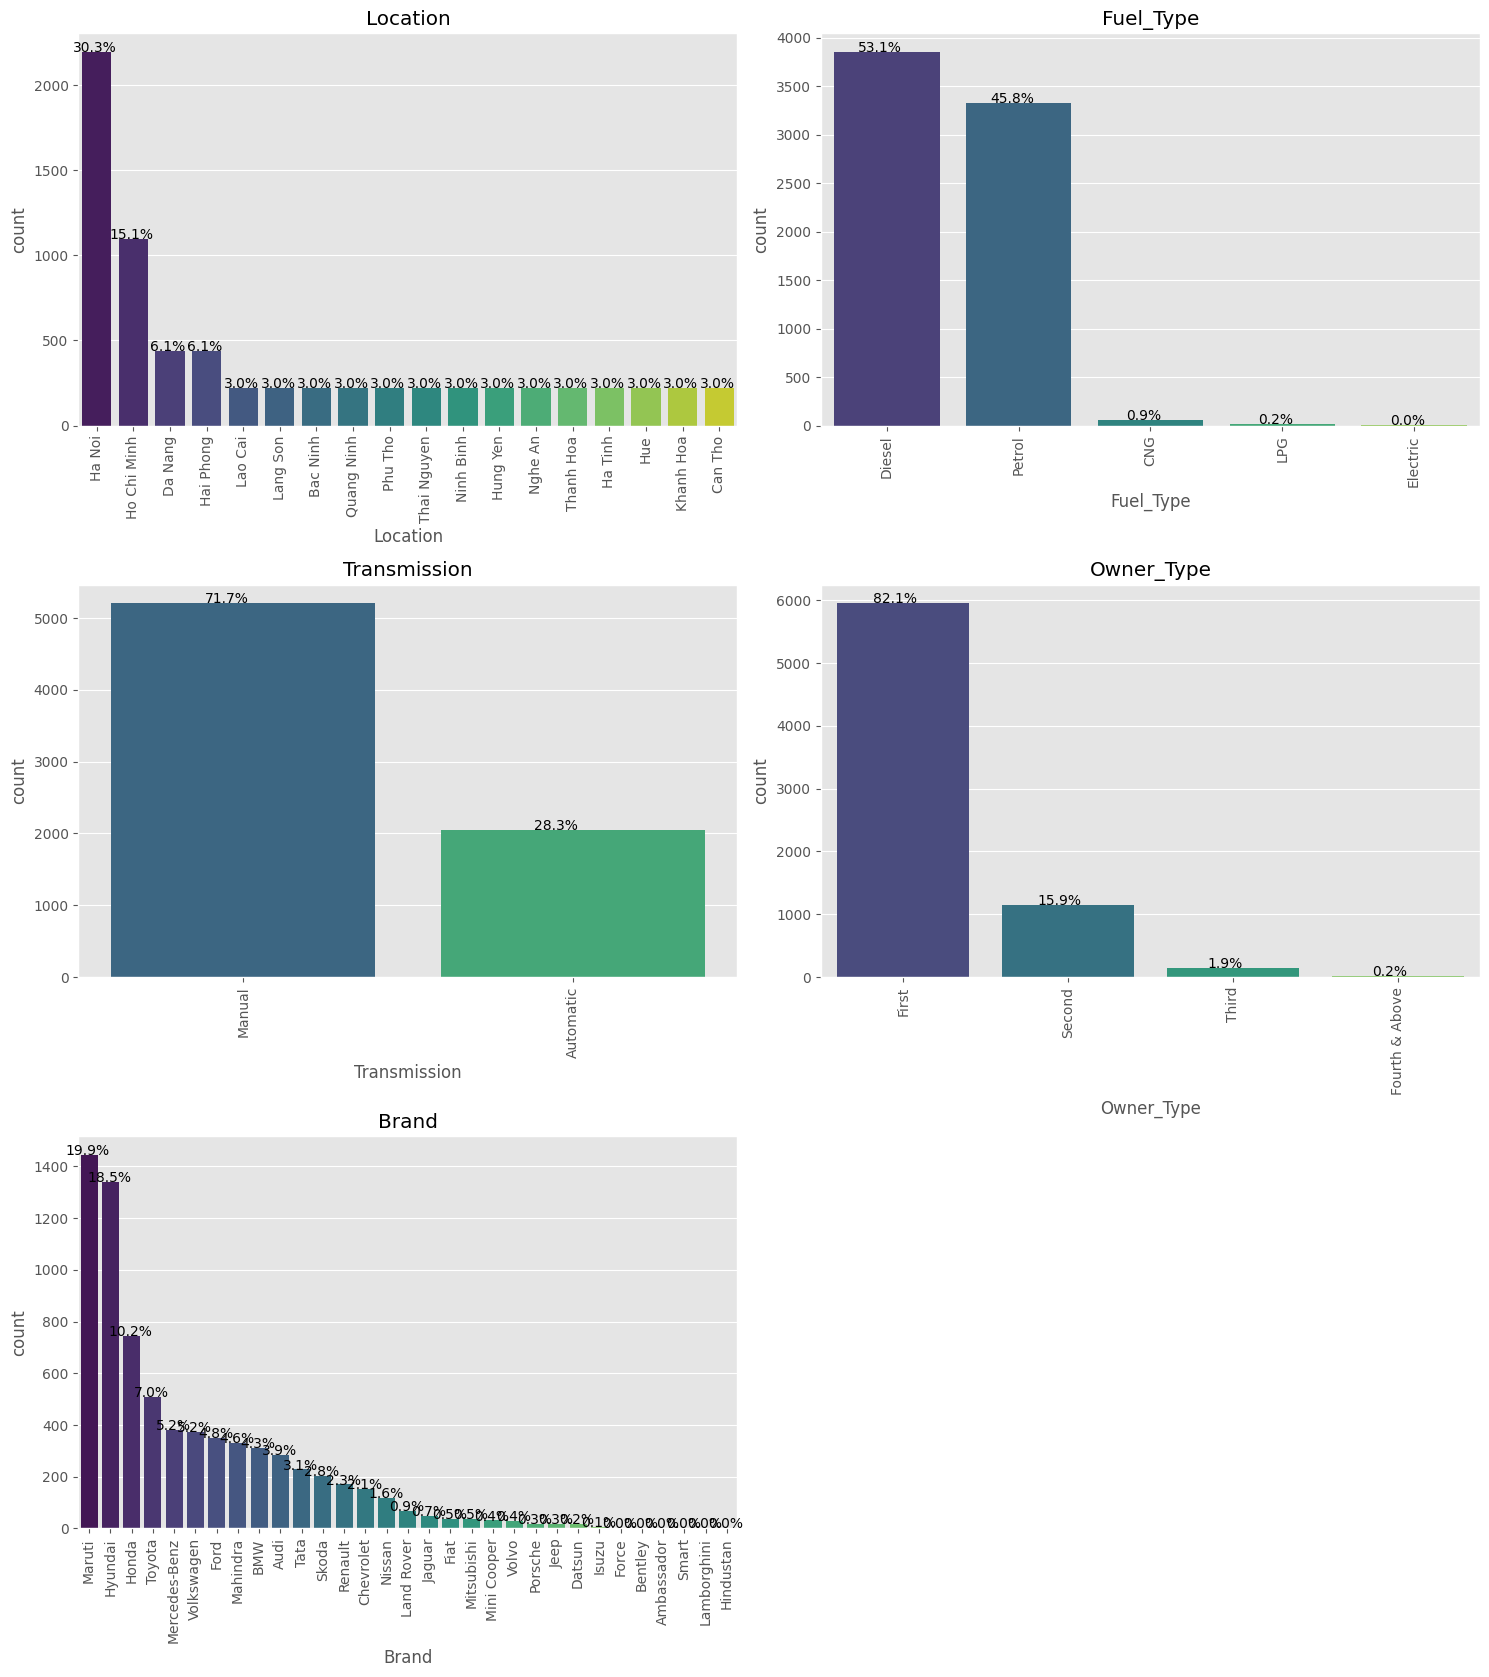

In [ ]:
cat_columns=['Location','Fuel_Type','Transmission', 'Owner_Type', 'Brand'] #cars.select_dtypes(exclude=np.number).columns.tolist()

plt.figure(figsize=(15,21))

for i, variable in enumerate(cat_columns):
                     plt.subplot(4,2,i+1)
                     order = cars[variable].value_counts(ascending=False).index
                     ax=sns.countplot(x=cars[variable], data=cars , order=order ,palette='viridis')
                     for p in ax.patches:
                           percentage = '{:.1f}%'.format(100 * p.get_height()/len(cars[variable]))
                           x = p.get_x() + p.get_width() / 2 - 0.05
                           y = p.get_y() + p.get_height()
                           plt.annotate(percentage, (x, y),ha='center')
                     plt.xticks(rotation=90)
                     plt.tight_layout()
                     plt.title(variable)


<p style = "font-size : 20px ; color: blue;font-family:TimesNewRoman">
    <b>Observations</b></p>
   
   **Car Profile**
    
Khoảng ~71% xe rao bán có hộp số sàn (Manual Transmission).

Khoảng ~82% là xe chủ đầu tiên (First owner).

Khoảng ~39% xe rao bán thuộc các hãng Maruti & Hyundai.

Khoảng ~53% xe rao bán/có thể mua có nhiên liệu Diesel.

Ha Noi có số lượng xe rao bán cao nhất, trong khi Lao Cai, Can Tho, Nghe An, Thanh Hoa, Hue, Ha Tinh,... là đều thấp nhất.

Phần lớn xe đều là 5 chỗ.

Xe rao bán/có thể mua có độ tuổi từ 6 đến 27 năm.

Khoảng ~71% xe thuộc phân khúc giá thấp.

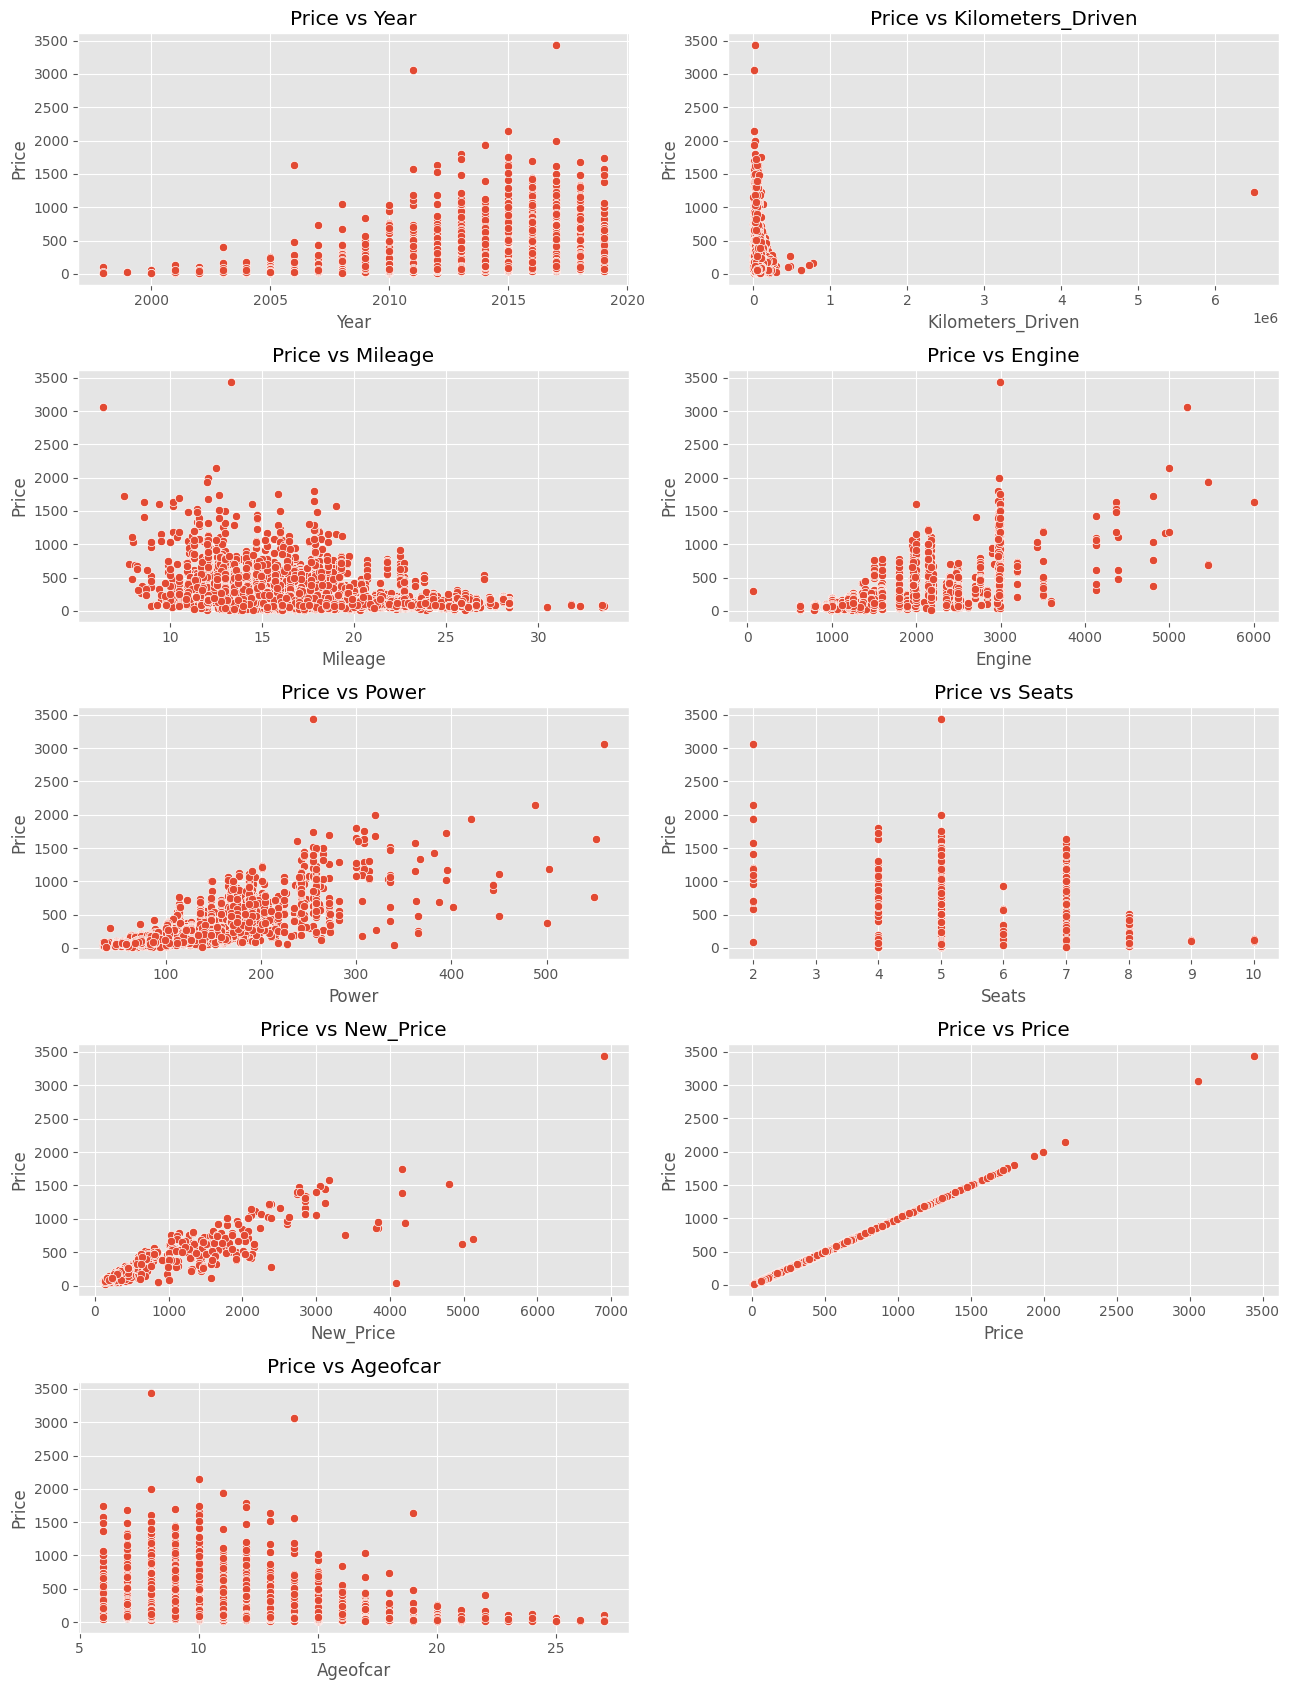

In [ ]:
numeric_columns= numeric_columns = cars.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(13,17))

for i, variable in enumerate(numeric_columns):
                     plt.subplot(5,2,i+1)
                     sns.scatterplot(x=cars[variable],y=cars['Price']).set(title='Price vs '+ variable)
                     #plt.xticks(rotation=90)
                     plt.tight_layout()

# Handling missing values

In [ ]:
cars.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,83
Engine,46
Power,175


### Calculating missing values in each row

In [ ]:
# counting the number of missing values per row
num_missing = cars.isnull().sum(axis=1)
num_missing.value_counts()

,count
1,5212
2,1112
0,819
3,57
4,31
5,20
6,1


In [ ]:
#Investigating how many missing values per row are there for each variable
for n in num_missing.value_counts().sort_index().index:
    if n > 0:
        print("*" *30,f'\nFor the rows with exactly {n} missing values, NAs are found in:')
        n_miss_per_col = cars[num_missing == n].isnull().sum()
        print(n_miss_per_col[n_miss_per_col > 0])
        print('\n\n')

****************************** 
For the rows with exactly 1 missing values, NAs are found in:
Mileage         5
New_Price    5025
Price         182
dtype: int64



****************************** 
For the rows with exactly 2 missing values, NAs are found in:
Mileage        25
Power          74
Seats           1
New_Price    1112
Price        1012
dtype: int64



****************************** 
For the rows with exactly 3 missing values, NAs are found in:
Mileage      35
Power        50
Seats         6
New_Price    57
Price        23
dtype: int64



****************************** 
For the rows with exactly 4 missing values, NAs are found in:
Mileage       6
Engine       25
Power        30
Seats        26
New_Price    31
Price         6
dtype: int64



****************************** 
For the rows with exactly 5 missing values, NAs are found in:
Mileage      11
Engine       20
Power        20
Seats        20
New_Price    20
Price         9
dtype: int64



****************************** 
Fo

Điều này xác nhận rằng một số cột có xu hướng bị thiếu cùng nhau hoặc tất cả đều không bị thiếu cùng nhau. Vì vậy, ta sẽ cố gắng điền các giá trị bị thiếu càng nhiều càng tốt.

In [ ]:
cars[num_missing==7]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar,Brand,Model
S.No.,,,,,,,,,,,,,,,,


In [ ]:
col=['Engine','Power','Mileage']
cars[col].isnull().sum()

,0
Engine,46
Power,175
Mileage,83


Ta có thể bắt đầu điền các giá trị còn thiếu bằng cách nhóm tên và năm và điền vào các giá trị còn thiếu với trung vị.

In [ ]:
cars.groupby(['Name','Year'])['Engine'].median().head(30)


Name                                           Year
Ambassador Classic Nova Diesel                 2003   1489.00000
Audi A3 35 TDI Attraction                      2014   1968.00000
Audi A3 35 TDI Premium                         2016   1968.00000
Audi A3 35 TDI Premium Plus                    2015   1968.00000
                                               2016   1968.00000
Audi A3 35 TDI Technology                      2017   1968.00000
Audi A4 1.8 TFSI                               2010   1781.00000
                                               2011   1781.00000
Audi A4 1.8 TFSI Technology Edition            2012   1798.00000
Audi A4 2.0 TDI                                2009   1968.00000
                                               2011   1968.00000
                                               2012   1968.00000
                                               2013   1968.00000
                                               2014   1968.00000
Audi A4 2.0 TDI 177 Bhp Premium Plus           2013   1968.00000
                                               2014   1968.00000
                                               2015   1968.00000
Audi A4 2.0 TDI 177 Bhp Technology Edition     2013   1968.00000
                                               2014   1968.00000
Audi A4 2.0 TDI Celebration Edition            2011   1968.00000
Audi A4 2.0 TDI Multitronic                    2009   1968.00000
                                               2010   1968.00000
                                               2011   1968.00000
                                               2012   1968.00000
                                               2013   1968.00000
                                               2014   1968.00000
                                               2015   1968.00000
Audi A4 2.0 TDI Premium Sport Limited Edition  2014   1968.00000
                                               2015   1968.00000
Audi A4 2.0 TFSI                               2011   1984.00000
Name: Engine, dtype: float64

In [ ]:
cars['Engine']=cars.groupby(['Name','Year'])['Engine'].transform(lambda x:x.fillna(x.median()))
cars['Power']=cars.groupby(['Name','Year'])['Power'].transform(lambda x:x.fillna(x.median()))
cars['Mileage']=cars.groupby(['Name','Year'])['Mileage'].transform(lambda x:x.fillna(x.median()))

In [ ]:
col=['Engine','Power','Mileage']
cars[col].isnull().sum()

,0
Engine,45
Power,162
Mileage,82


In [ ]:
cars.groupby(['Brand','Model'])['Engine'].median().head(10)

Brand       Model      
Ambassador  ClassicNova   1489.00000
Audi        A335          1968.00000
            A41.8         1781.00000
            A42.0         1968.00000
            A43.0         2967.00000
            A43.2         3197.00000
            A430          1395.00000
            A435          1968.00000
            A4New         1968.00000
            A62.0         1968.00000
Name: Engine, dtype: float64

Như ta có thể thấy, hầu hết các mô hình đều có cùng kích thước động cơ và thay vì chỉ áp dụng giá trị trung vị, việc nhóm theo mô hình và năm sẽ cung cấp thông tin chi tiết hơn và giá trị Engine gần chính xác hơn.

In [ ]:
#chosing Median to fill the the missing value as there are many outliers,
#grouping by model and year to get  more granularity and more accurate Engine and then fillig with median
cars['Engine']=cars.groupby(['Brand','Model'])['Engine'].transform(lambda x:x.fillna(x.median()))


In [ ]:
#chosing Median to fill the the missing value as there are many outliers,
#grouping by model to get more granularity and more accurate Engine
cars['Power']=cars.groupby(['Brand','Model'])['Power'].transform(lambda x:x.fillna(x.median()))

In [ ]:
#chosing Median to fill the the missing value as there are many outliers,
#grouping by model to get more granularity and more accurate Engine
cars['Mileage']=cars.groupby(['Brand','Model'])['Mileage'].transform(lambda x:x.fillna(x.median()))


In [ ]:
col=['Engine','Power','Mileage']
cars[col].isnull().sum()


,0
Engine,18
Power,63
Mileage,32


Vẫn còn thiếu giá trị, cần phân tích thêm. Chỉ nhóm theo Model cho Engine và sau đó điền giá trị còn thiếu bằng giá trị trung vị. Đối với Power và Kilimeters_Drive, có thể sử dụng giá trị Power cho một Brand để có được giá trị chính xác hơn.

In [ ]:
cars.groupby(['Model','Year'])['Engine'].agg({'median','mean','max'}).sort_values(by='Model',ascending=True).head(10)

max       mean     median
Model   Year                                 
1000AC  1998  970.00000  970.00000  970.00000
1Series 2013 1995.00000 1995.00000 1995.00000
        2015 1995.00000 1995.00000 1995.00000
370ZAT  2012 3696.00000 3696.00000 3696.00000
3Series 2018 1995.00000 1995.00000 1995.00000
        2017 1995.00000 1995.00000 1995.00000
        2016 1995.00000 1995.00000 1995.00000
        2015 1995.00000 1995.00000 1995.00000
        2014 2993.00000 2078.16667 1995.00000
        2013 2993.00000 2066.42857 1995.00000

In [ ]:
cars.groupby(['Brand','Engine'])['Power'].agg({'mean','median','max'}).head(10)

max      mean    median
Brand      Engine                                  
Ambassador 1489.00000  35.50000  35.50000  35.50000
Audi       1395.00000 147.51000 147.51000 147.51000
           1781.00000 163.20000 163.20000 163.20000
           1798.00000 187.74000 181.03333 187.74000
           1968.00000 187.74000 167.12318 174.33000
           1984.00000 226.60000 196.02200 207.90000
           2698.00000 179.50000 179.50000 179.50000
           2773.00000 201.00000 201.00000 201.00000
           2894.00000 444.00000 444.00000 444.00000
           2967.00000 246.70000 241.74000 241.40000

In [ ]:
cars['Seats'].isnull().sum()

np.int64(54)

Nhóm theo Name sẽ cung cấp cho tôi thông tin chi tiết hơn và giá trị Seats gần chính xác hơn.

In [ ]:
cars['Seats']=cars.groupby(['Name'])['Seats'].transform(lambda x:x.fillna(x.median()))

In [ ]:
cars['Seats'].isnull().sum()

np.int64(47)

Nhóm với Model sẽ cung cấp cho tôi thông tin chi tiết hơn và giá trị Seats gần chính xác hơn.

In [ ]:
cars['Seats']=cars.groupby(['Model'])['Seats'].transform(lambda x:x.fillna(x.median()))

In [ ]:
cars['Seats'].isnull().sum()

np.int64(23)

 Check loại xe nào đang có missing values.

In [ ]:
cars[cars['Seats'].isnull()==True].head(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar,Brand,Model
S.No.,,,,,,,,,,,,,,,,
208,Maruti Swift 1.3 VXi,Ha Noi,2010,42001,Petrol,Manual,First,16.10000,NaN,NaN,NaN,NaN,54.00000,15,Maruti,Swift1.3
733,Maruti Swift 1.3 VXi,Ha Noi,2006,97800,Petrol,Manual,Third,16.10000,NaN,NaN,NaN,NaN,48.00000,19,Maruti,Swift1.3
1327,Maruti Swift 1.3 ZXI,Ha Noi,2015,50295,Petrol,Manual,First,16.10000,NaN,NaN,NaN,NaN,130.00000,10,Maruti,Swift1.3
2074,Maruti Swift 1.3 LXI,Ho Chi Minh,2011,24255,Petrol,Manual,First,16.10000,NaN,NaN,NaN,NaN,80.00000,14,Maruti,Swift1.3
2325,Maruti Swift 1.3 VXI ABS,Thanh Hoa,2015,67000,Petrol,Manual,First,16.10000,NaN,NaN,NaN,NaN,105.00000,10,Maruti,Swift1.3
2335,Maruti Swift 1.3 VXi,Ho Chi Minh,2007,55000,Petrol,Manual,Second,16.10000,NaN,NaN,NaN,NaN,48.00000,18,Maruti,Swift1.3
2369,Maruti Estilo LXI,Ho Chi Minh,2008,56000,Petrol,Manual,Second,19.50000,1061.00000,NaN,NaN,NaN,42.00000,17,Maruti,EstiloLXI
2668,Maruti Swift 1.3 VXi,Ho Chi Minh,2014,32986,Petrol,Manual,First,16.10000,NaN,NaN,NaN,NaN,99.00000,11,Maruti,Swift1.3
3404,Maruti Swift 1.3 VXi,Ha Noi,2006,125000,Petrol,Manual,Fourth & Above,16.10000,NaN,NaN,NaN,NaN,62.00000,19,Maruti,Swift1.3


In [ ]:
#most of cars are 5 seater so fillrest of 23 by 5
cars['Seats']=cars['Seats'].fillna(5)

In [ ]:
cars['Seats'].isnull().sum()

np.int64(0)

Cần phân tích cùng với Price xem liệu Seats có đóng vai trò gì trong giá không

In [ ]:

cars["Location"] = cars["Location"].astype("category")
cars['Brand'] =cars['Brand'].astype("category")

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7252 entries, 0 to 7252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Name               7252 non-null   object  
 1   Location           7252 non-null   category
 2   Year               7252 non-null   int64   
 3   Kilometers_Driven  7252 non-null   int64   
 4   Fuel_Type          7252 non-null   category
 5   Transmission       7252 non-null   category
 6   Owner_Type         7252 non-null   category
 7   Mileage            7220 non-null   float64 
 8   Engine             7234 non-null   float64 
 9   Power              7189 non-null   float64 
 10  Seats              7252 non-null   float64 
 11  New_Price          1006 non-null   float64 
 12  Price              6019 non-null   float64 
 13  Ageofcar           7252 non-null   int64   
 14  Brand              7252 non-null   category
 15  Model              7252 non-null   object  
dtypes: category

# Processing New Price

In [ ]:
#For better granualarity grouping has there would be same car model present so filling with a median value brings it more near to real value
cars['New_Price']=cars.groupby(['Name','Year'])['New_Price'].transform(lambda x:x.fillna(x.median()))

In [ ]:
cars.New_Price.isnull().sum()

np.int64(6138)

In [ ]:
cars['New_Price']=cars.groupby(['Name'])['New_Price'].transform(lambda x:x.fillna(x.median()))

In [ ]:
cars.New_Price.isnull().sum()

np.int64(6019)

In [ ]:
cars['New_Price']=cars.groupby(['Brand','Model'])['New_Price'].transform(lambda x:x.fillna(x.median()))

In [ ]:
cars.New_Price.isnull().sum()

np.int64(4578)

In [ ]:
cars['New_Price']=cars.groupby(['Brand'])['New_Price'].transform(lambda x:x.fillna(x.median()))

In [ ]:
cars.New_Price.isnull().sum()

np.int64(158)

In [ ]:
cars.groupby(['Brand'])['New_Price'].median().sort_values(ascending=False)

,New_Price
Brand,
Bentley,11250.00000
Land Rover,4170.00000
Porsche,4080.00000
BMW,1652.10000
Jaguar,1611.60000
Audi,1594.20000
Mercedes-Benz,1484.70000
Volvo,1370.10000
Mini Cooper,1269.00000


In [ ]:
cars.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,32
Engine,18
Power,63


In [ ]:
cols1 = ["Power","Mileage","Engine"]

for ii in cols1:
    cars[ii] = cars[ii].fillna(cars[ii].median())

In [ ]:
#dropping remaining rows
#cannot further fill this rows so dropping them

cars.dropna(inplace=True,axis=0)

In [ ]:
cars.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0
Power,0


In [ ]:
cars.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar,Brand,Model
S.No.,,,,,,,,,,,,,,,,
0,Maruti Wagon R LXI CNG,Ha Noi,2010,72000,CNG,Manual,First,26.60000,998.00000,58.16000,5.00000,158.70000,45.00000,15,Maruti,WagonR
1,Hyundai Creta 1.6 CRDi SX Option,Lao Cai,2015,41000,Diesel,Manual,First,19.67000,1582.00000,126.20000,5.00000,481.80000,299.00000,10,Hyundai,Creta1.6
2,Honda Jazz V,Ha Noi,2011,46000,Petrol,Manual,First,18.20000,1199.00000,88.70000,5.00000,258.30000,122.00000,14,Honda,JazzV
3,Maruti Ertiga VDI,Ha Noi,2012,87000,Diesel,Manual,First,20.77000,1248.00000,88.76000,7.00000,338.10000,147.00000,13,Maruti,ErtigaVDI
4,Audi A4 New 2.0 TDI Multitronic,Lang Son,2013,40670,Diesel,Automatic,Second,15.20000,1968.00000,140.80000,5.00000,1594.20000,416.00000,12,Audi,A4New


In [ ]:
cars.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0
Power,0


In [ ]:
df.shape

(7253, 13)

Đã xử lý hết missing values

In [ ]:
cars.groupby(['Brand'])['Price'].agg({'median','mean','max'})

,max,mean,median
Brand,,,
Ambassador,NaN,NaN,NaN
Audi,1440.00000,547.94915,501.00000
BMW,1999.00000,549.25094,464.00000
Bentley,1633.00000,1633.00000,1633.00000
Chevrolet,NaN,NaN,NaN
Datsun,89.00000,69.38462,70.00000
Fiat,159.00000,77.60714,65.00000
Force,NaN,NaN,NaN
Ford,1169.00000,157.05667,123.00000


In [ ]:
Low = [
    'Maruti',
    'Tata',
    'Mahindra',
    'Renault',
    'Datsun',
    'Fiat',
    'Hindustan',
    'Ambassdor',
    'Force',
    'Smart'
]

Mid = [
    'Hyundai',
    'Honda',
    'Toyota',
    'Skoda',
    'Volkswagen',
    'Nissan',
    'Ford',
    'Mitsubishi',
    'Isuzu',
    'Chevrolet'
]

High = [
    'Audi',
    'Mini Cooper',
    'Bentley',
    'Mercedes-Benz',
    'Lamborghini',
    'Porsche',
    'Land Rover',
    'Volvo',
    'Jeep',
    'Jaguar',
    'BMW'
]

In [ ]:
def classrange(x):
    if x in Low:
        return "Low"
    elif x in Mid:
        return "Mid"
    elif x in High:
        return "High"
    else:
        return x

In [ ]:
cars['Brand_Class'] = cars['Brand'].apply(lambda x: classrange(x))

In [ ]:
cars['Brand_Class'].unique()

array(['Low', 'Mid', 'High'], dtype=object)

In [ ]:
cars['Engine']=cars['Engine'].astype(int)
cars['Brand_Class']=cars["Brand_Class"].astype('category')

### Bivariate & Multivariate Analysis

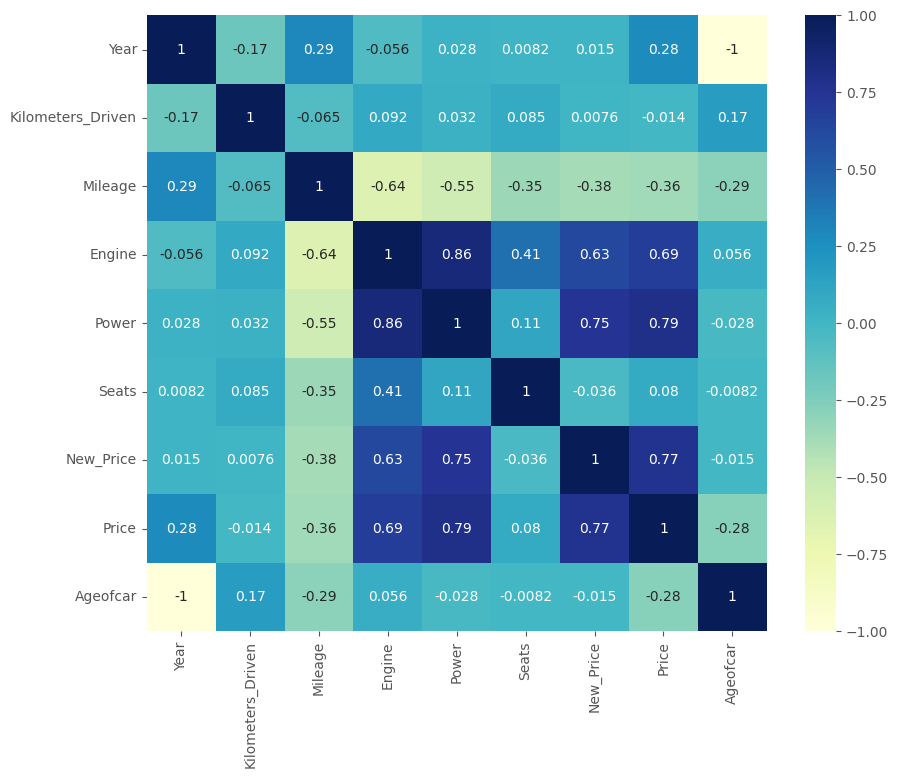

In [ ]:
plt.figure(figsize=(10,8))
# Select only numerical columns for correlation calculation
numerical_cars = cars.select_dtypes(include=np.number)
sns.heatmap(numerical_cars.corr(),annot=True ,cmap="YlGnBu" )
plt.show()

<p style = "font-size : 20px ; color: blue;font-family:TimesNewRoman">
    <b>Observations</b></p>

    
Engine có tương quan dương mạnh với Power (0.86).

Price tương quan dương với Engine (0.66) và Power (0.77).

Mileage tương quan âm với Engine, Power, Price và Age of car.

Price tương quan âm với Age of car.

Kilometer driven không ảnh hưởng đáng kể đến Price.


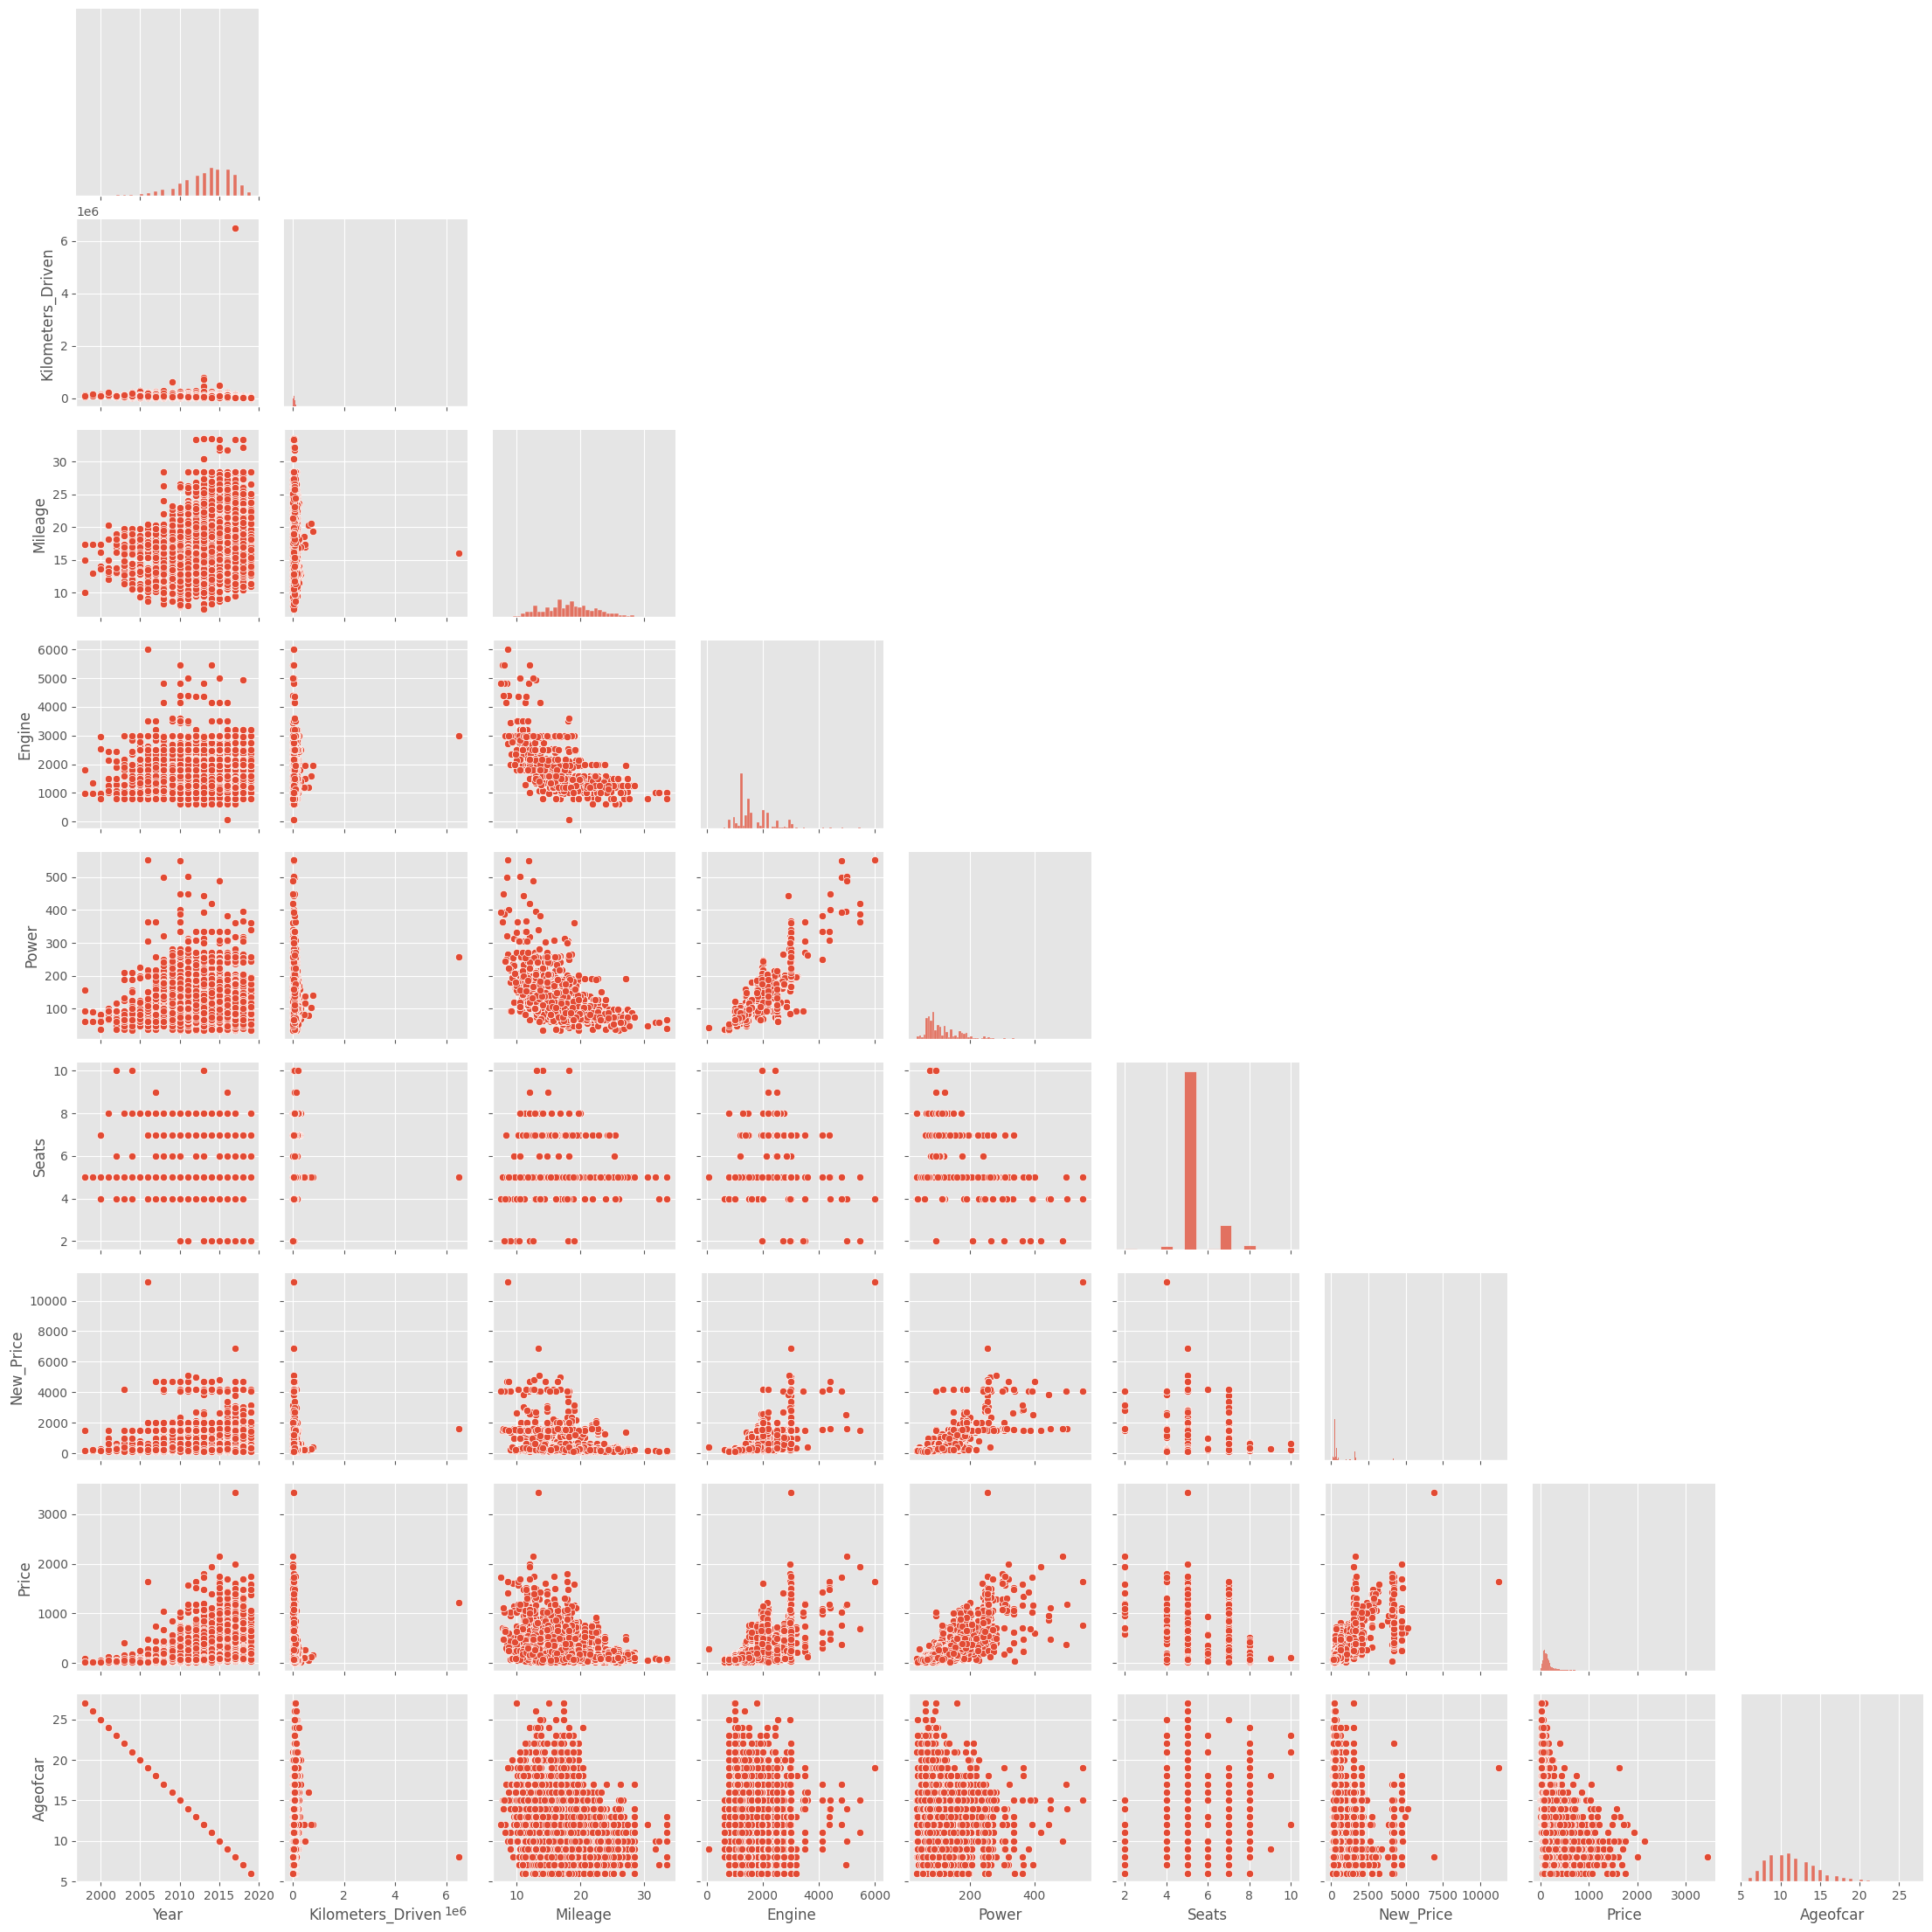

In [ ]:
sns.pairplot(data=cars , corner=True)
plt.show()

<p style = "font-size : 15px ; color: blue;font-family:TimesNewRoman">
    <b>Observations</b></p>
    
Kilometer driven không ảnh hưởng đáng kể đến Price.

Power tăng thì Mileage giảm.

Xe đời mới hơn bán với giá cao hơn.

Khi Engine và Power tăng, giá xe có xu hướng tăng.

### Variables that are correlated with Price variable

#### Price  Vs Engine Vs Transmission

<Axes: title={'center': 'Price VS Engine based on Transmission'}, xlabel='Price', ylabel='Engine'>

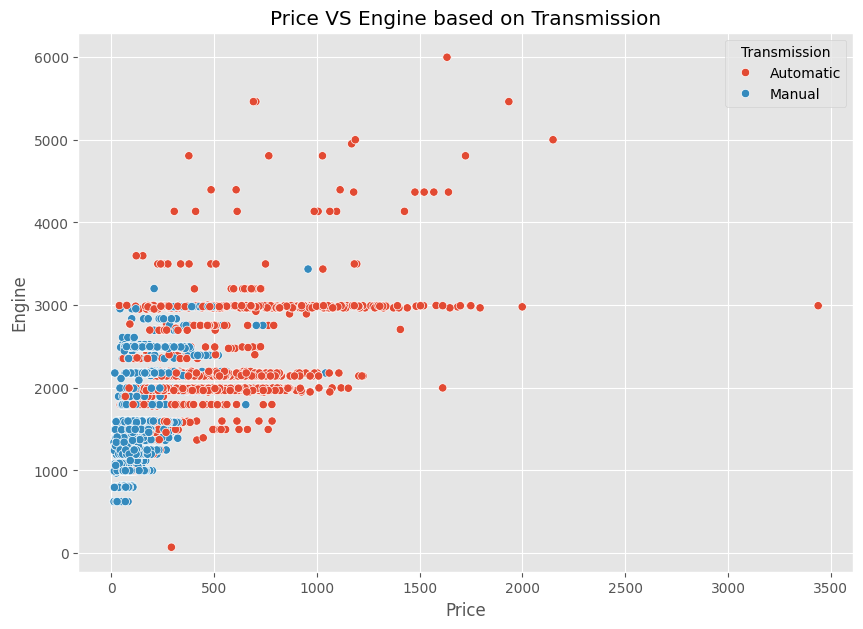

In [ ]:
# understand relation ship of Engine vs Price and Transmimssion
plt.figure(figsize=(10,7))

plt.title("Price VS Engine based on Transmission")
sns.scatterplot(y='Engine', x='Price', hue='Transmission', data=cars)

#### Price Vs Power vs Transmission

<Axes: title={'center': 'Price vs Power based on Transmission'}, xlabel='Price', ylabel='Power'>

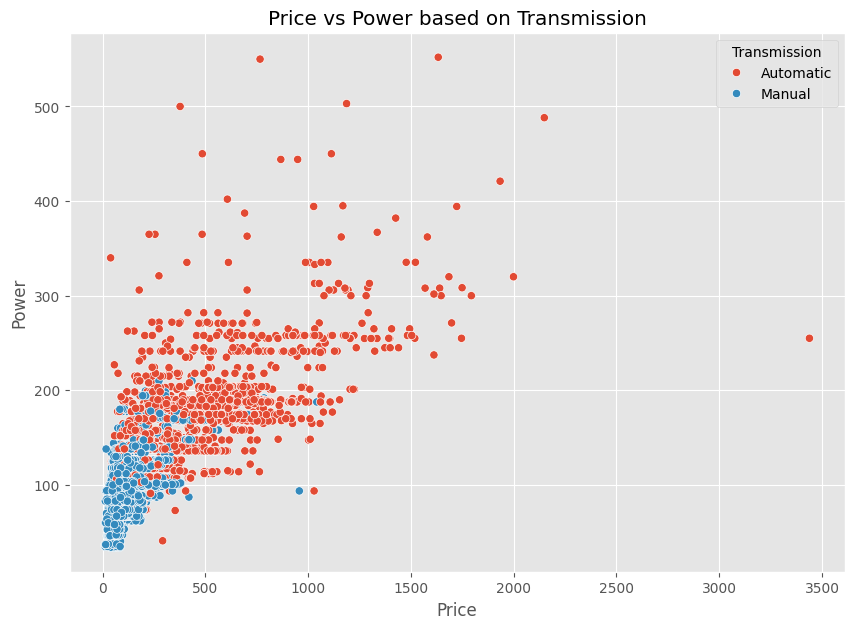

In [ ]:
 #understand relationship betweem Price and Power
plt.figure(figsize=(10,7))
plt.title("Price vs Power based on Transmission")
sns.scatterplot(y='Power', x='Price', hue='Transmission', data=cars)

#### Price Vs Mileage Vs Transmission

<Axes: xlabel='Price', ylabel='Mileage'>

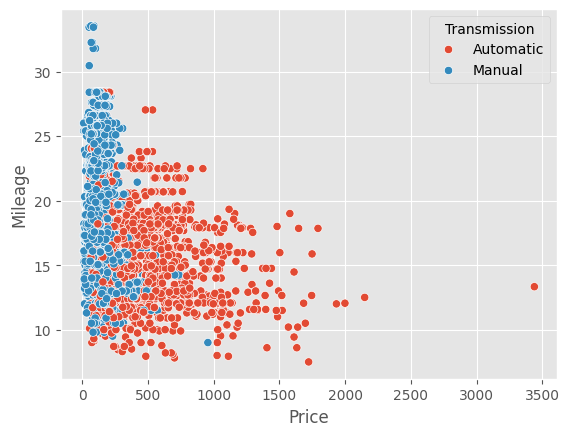

In [ ]:
# Understand the relationships  between mileage and Price
sns.scatterplot(y='Mileage', x='Price', hue='Transmission', data=cars)

#### Price Vs Year Vs Transmission

<Axes: title={'center': 'Price based on manufacturing Year of model'}, xlabel='Year', ylabel='Price'>

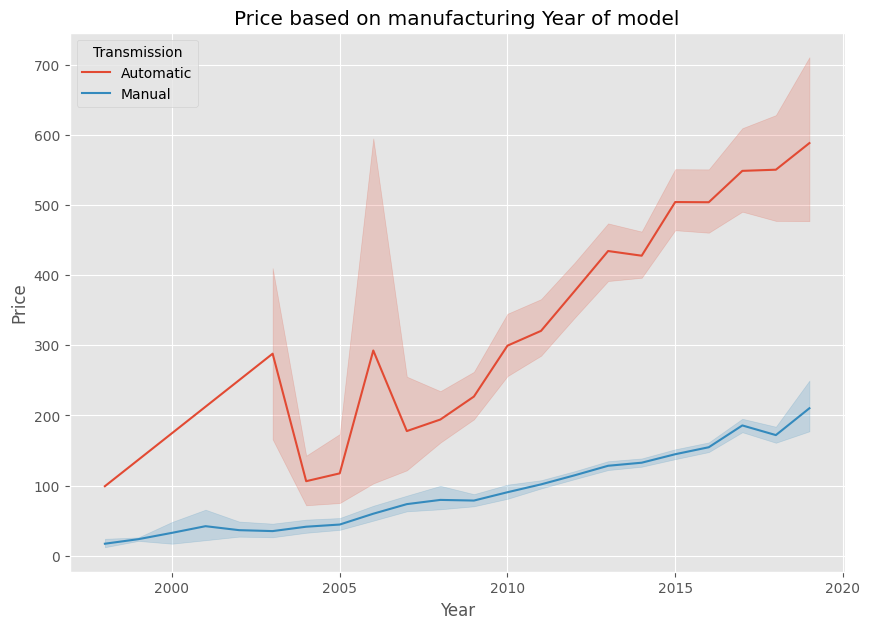

In [ ]:
# Impact of years on price
plt.figure(figsize=(10,7))
plt.title("Price based on manufacturing Year of model")
sns.lineplot(x='Year', y='Price',hue='Transmission',
             data=cars)


#### Price Vs Year VS Fuel Type

<Axes: title={'center': 'Price Vs Year VS FuelType'}, xlabel='Year', ylabel='Price'>

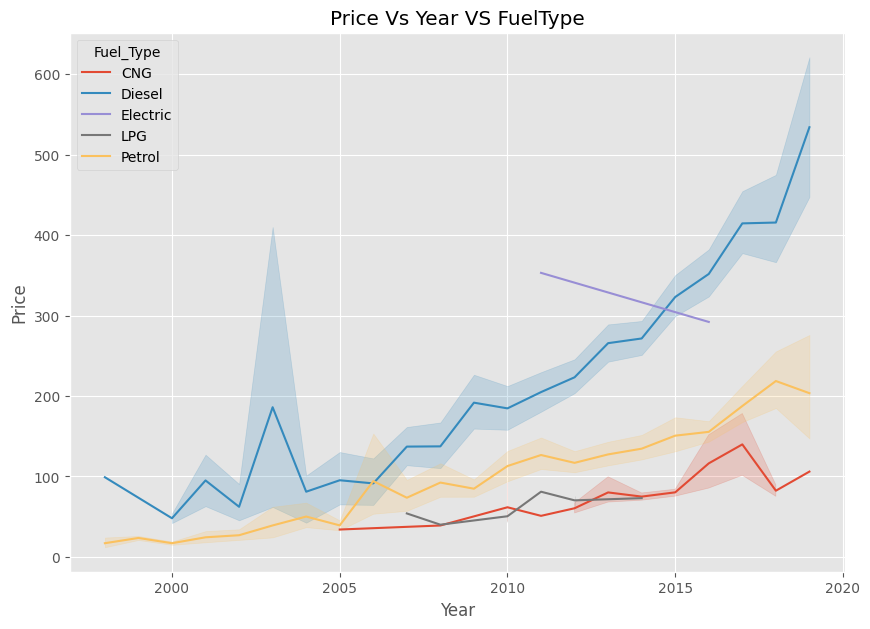

In [ ]:
# Impact of years on price
plt.figure(figsize=(10,7))
plt.title("Price Vs Year VS FuelType")
sns.lineplot(x='Year', y='Price',hue='Fuel_Type',
             data=cars)

#### Year Vs Price Vs Owner_Type

<Axes: title={'center': 'Price Vs Year VS Owner_Type'}, xlabel='Year', ylabel='Price'>

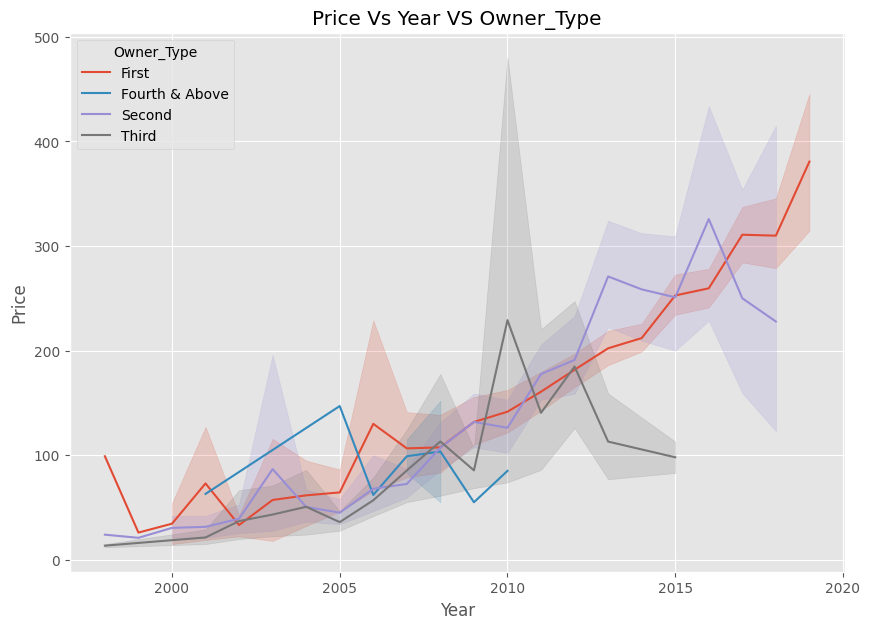

In [ ]:
plt.figure(figsize=(10,7))
plt.title("Price Vs Year VS Owner_Type")
sns.lineplot(x='Year', y='Price',hue='Owner_Type',
             data=cars)

Need to check the reason for spike in price  for third owner and model in 2010.

In [ ]:
cars[(cars["Owner_Type"]=='Third') & (cars["Year"].isin([2010]))].sort_values(by='Price',ascending =False)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar,Brand,Model,Brand_Class
S.No.,,,,,,,,,,,,,,,,,
2978,Porsche Panamera 2010 2013 4S,Phu Tho,2010,42400,Petrol,Automatic,Third,8.00000,4806,394.30000,4.00000,4080.00000,1027.00000,15,Porsche,Panamera2010,High
5404,BMW 5 Series 2003-2012 520d,Ho Chi Minh,2010,170000,Diesel,Automatic,Third,18.48000,1995,177.00000,5.00000,2036.10000,269.00000,15,BMW,5Series,High
3293,Toyota Innova 2.5 GX 7 STR,Ho Chi Minh,2010,140000,Diesel,Manual,Third,12.80000,2494,102.00000,7.00000,632.55000,166.00000,15,Toyota,Innova2.5,Mid
4962,Mahindra Scorpio VLX,Hai Phong,2010,144400,Diesel,Manual,Third,12.05000,2179,120.00000,8.00000,327.00000,128.00000,15,Mahindra,ScorpioVLX,Low
3479,Volkswagen Passat 1.8 TSI MT,Ninh Binh,2010,60000,Petrol,Manual,Third,14.30000,1798,160.00000,5.00000,328.20000,87.00000,15,Volkswagen,Passat1.8,Mid
1629,Maruti Swift Lxi BSIII,Hai Phong,2010,54898,Petrol,Manual,Third,16.10000,1298,88.20000,5.00000,210.00000,64.00000,15,Maruti,SwiftLxi,Low
5351,Volkswagen Polo Petrol Highline 1.2L,Ha Noi,2010,79000,Petrol,Manual,Third,16.47000,1198,73.90000,5.00000,328.20000,61.00000,15,Volkswagen,PoloPetrol,Mid
698,Ford Figo Diesel ZXI,Ha Noi,2010,100002,Diesel,Manual,Third,20.00000,1399,68.00000,5.00000,344.25000,31.00000,15,Ford,FigoDiesel,Mid


The observation is for The Porsche Panamera is expensive and luxury car so the data is valid.

In [ ]:
cars.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar
count,5892.00000,5892.00000,5892.00000,5892.00000,5892.00000,5892.00000,5892.00000,5892.00000,5892.00000
mean,2013.39766,58655.30109,18.32189,1625.08452,113.00404,5.27834,572.87201,218.07162,11.60234
std,3.26869,92128.10804,4.16939,600.79522,53.52478,0.79759,682.28734,234.59547,3.26869
min,1998.00000,171.00000,7.50000,72.00000,34.20000,2.00000,117.30000,11.00000,6.00000
25%,2012.00000,33736.75000,15.30000,1198.00000,75.00000,5.00000,242.10000,87.00000,9.00000
50%,2014.00000,53000.00000,18.20000,1493.00000,93.70000,5.00000,289.95000,135.00000,11.00000
75%,2016.00000,72683.25000,21.10000,1984.00000,138.10000,5.00000,493.50000,238.00000,13.00000
max,2019.00000,6500000.00000,33.54000,5998.00000,552.00000,10.00000,11250.00000,3439.00000,27.00000


#### Price Vs Mileage vs Fuel_type

<Axes: title={'center': 'Price Vs Mileage'}, xlabel='Mileage', ylabel='Price'>

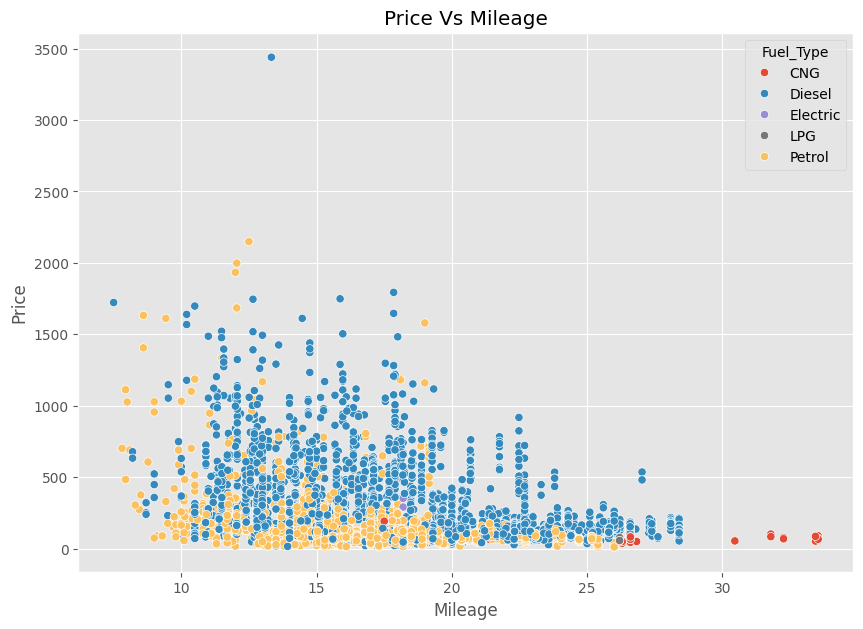

In [ ]:
# Understand relationships  between price and mileage
plt.figure(figsize=(10,7))
plt.title("Price Vs Mileage")
sns.scatterplot(y='Price', x='Mileage', hue='Fuel_Type', data=cars)

#### Price Vs Seat

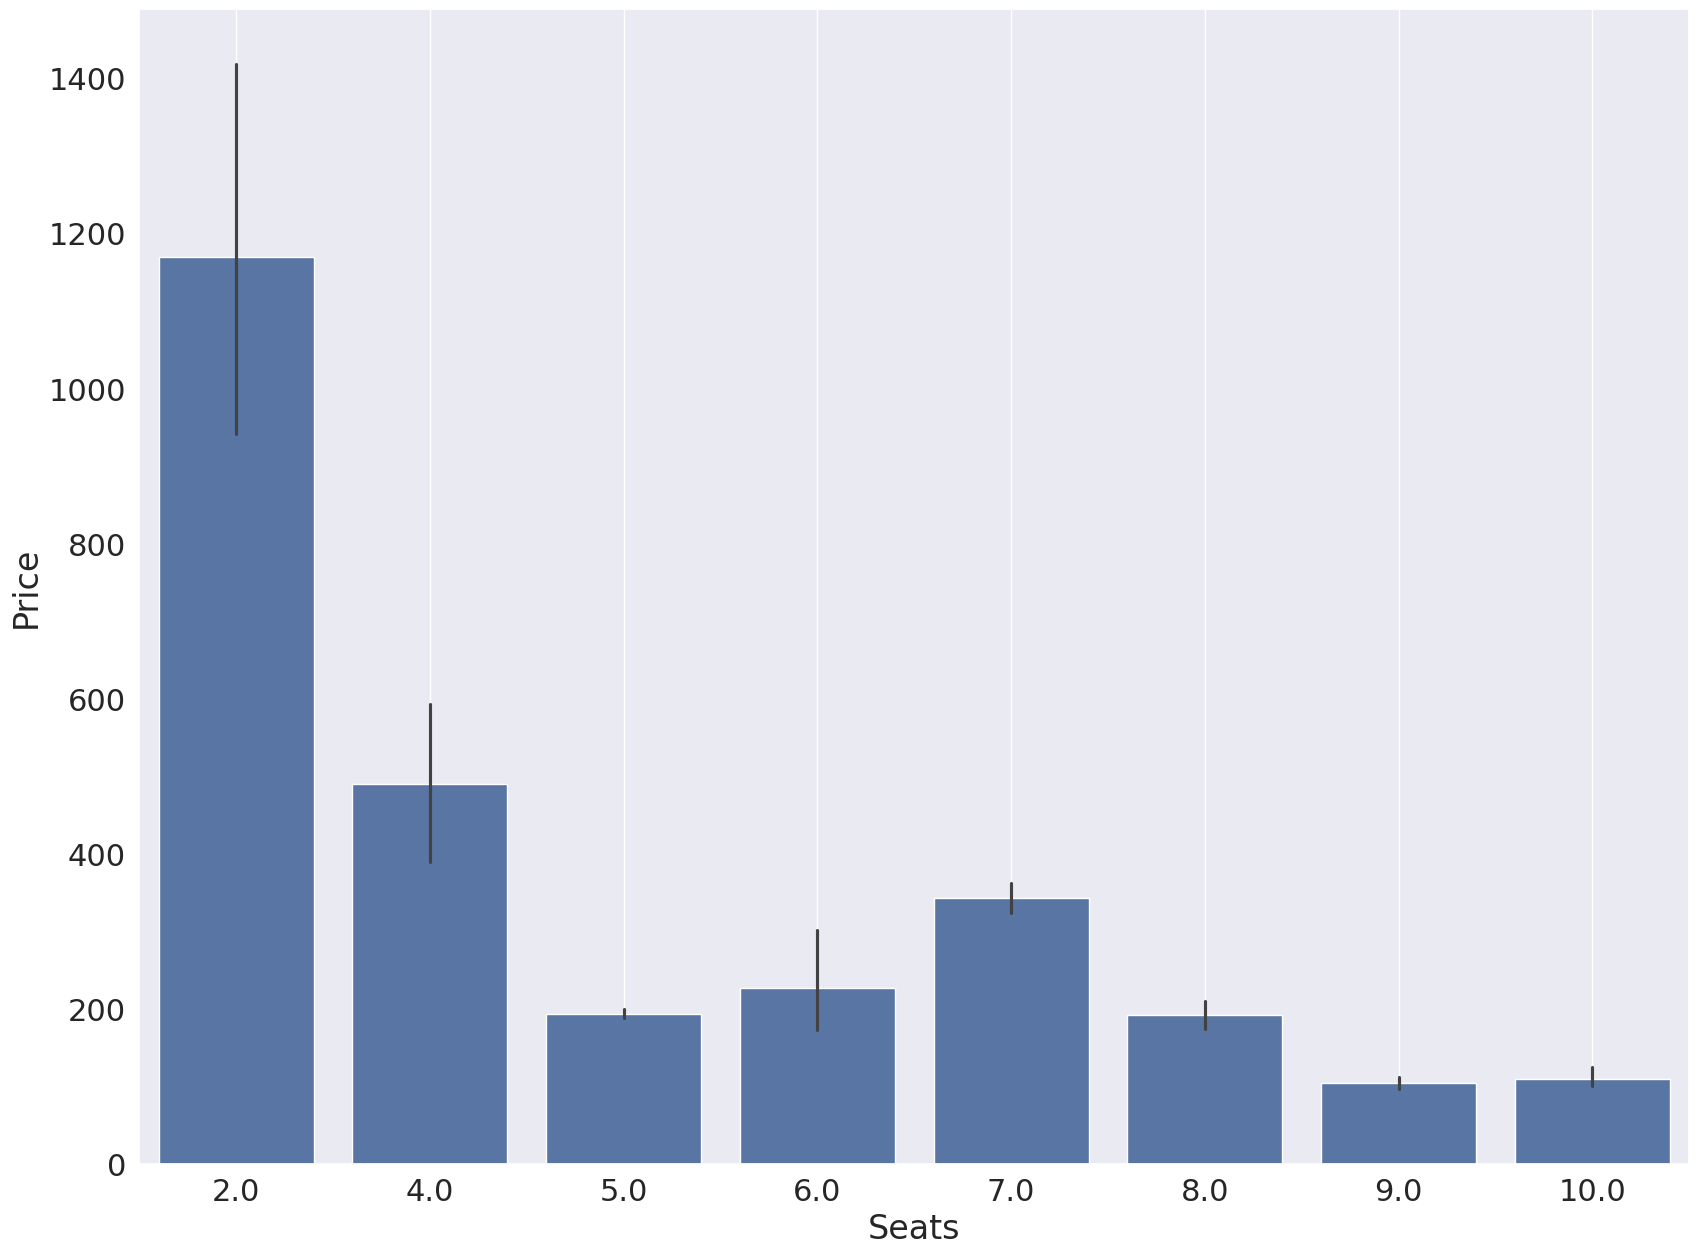

In [ ]:
#Price and seats
plt.figure(figsize=(20,15))
sns.set(font_scale=2)
sns.barplot(x='Seats', y='Price', data=cars)
plt.grid()

#### Price Vs Location

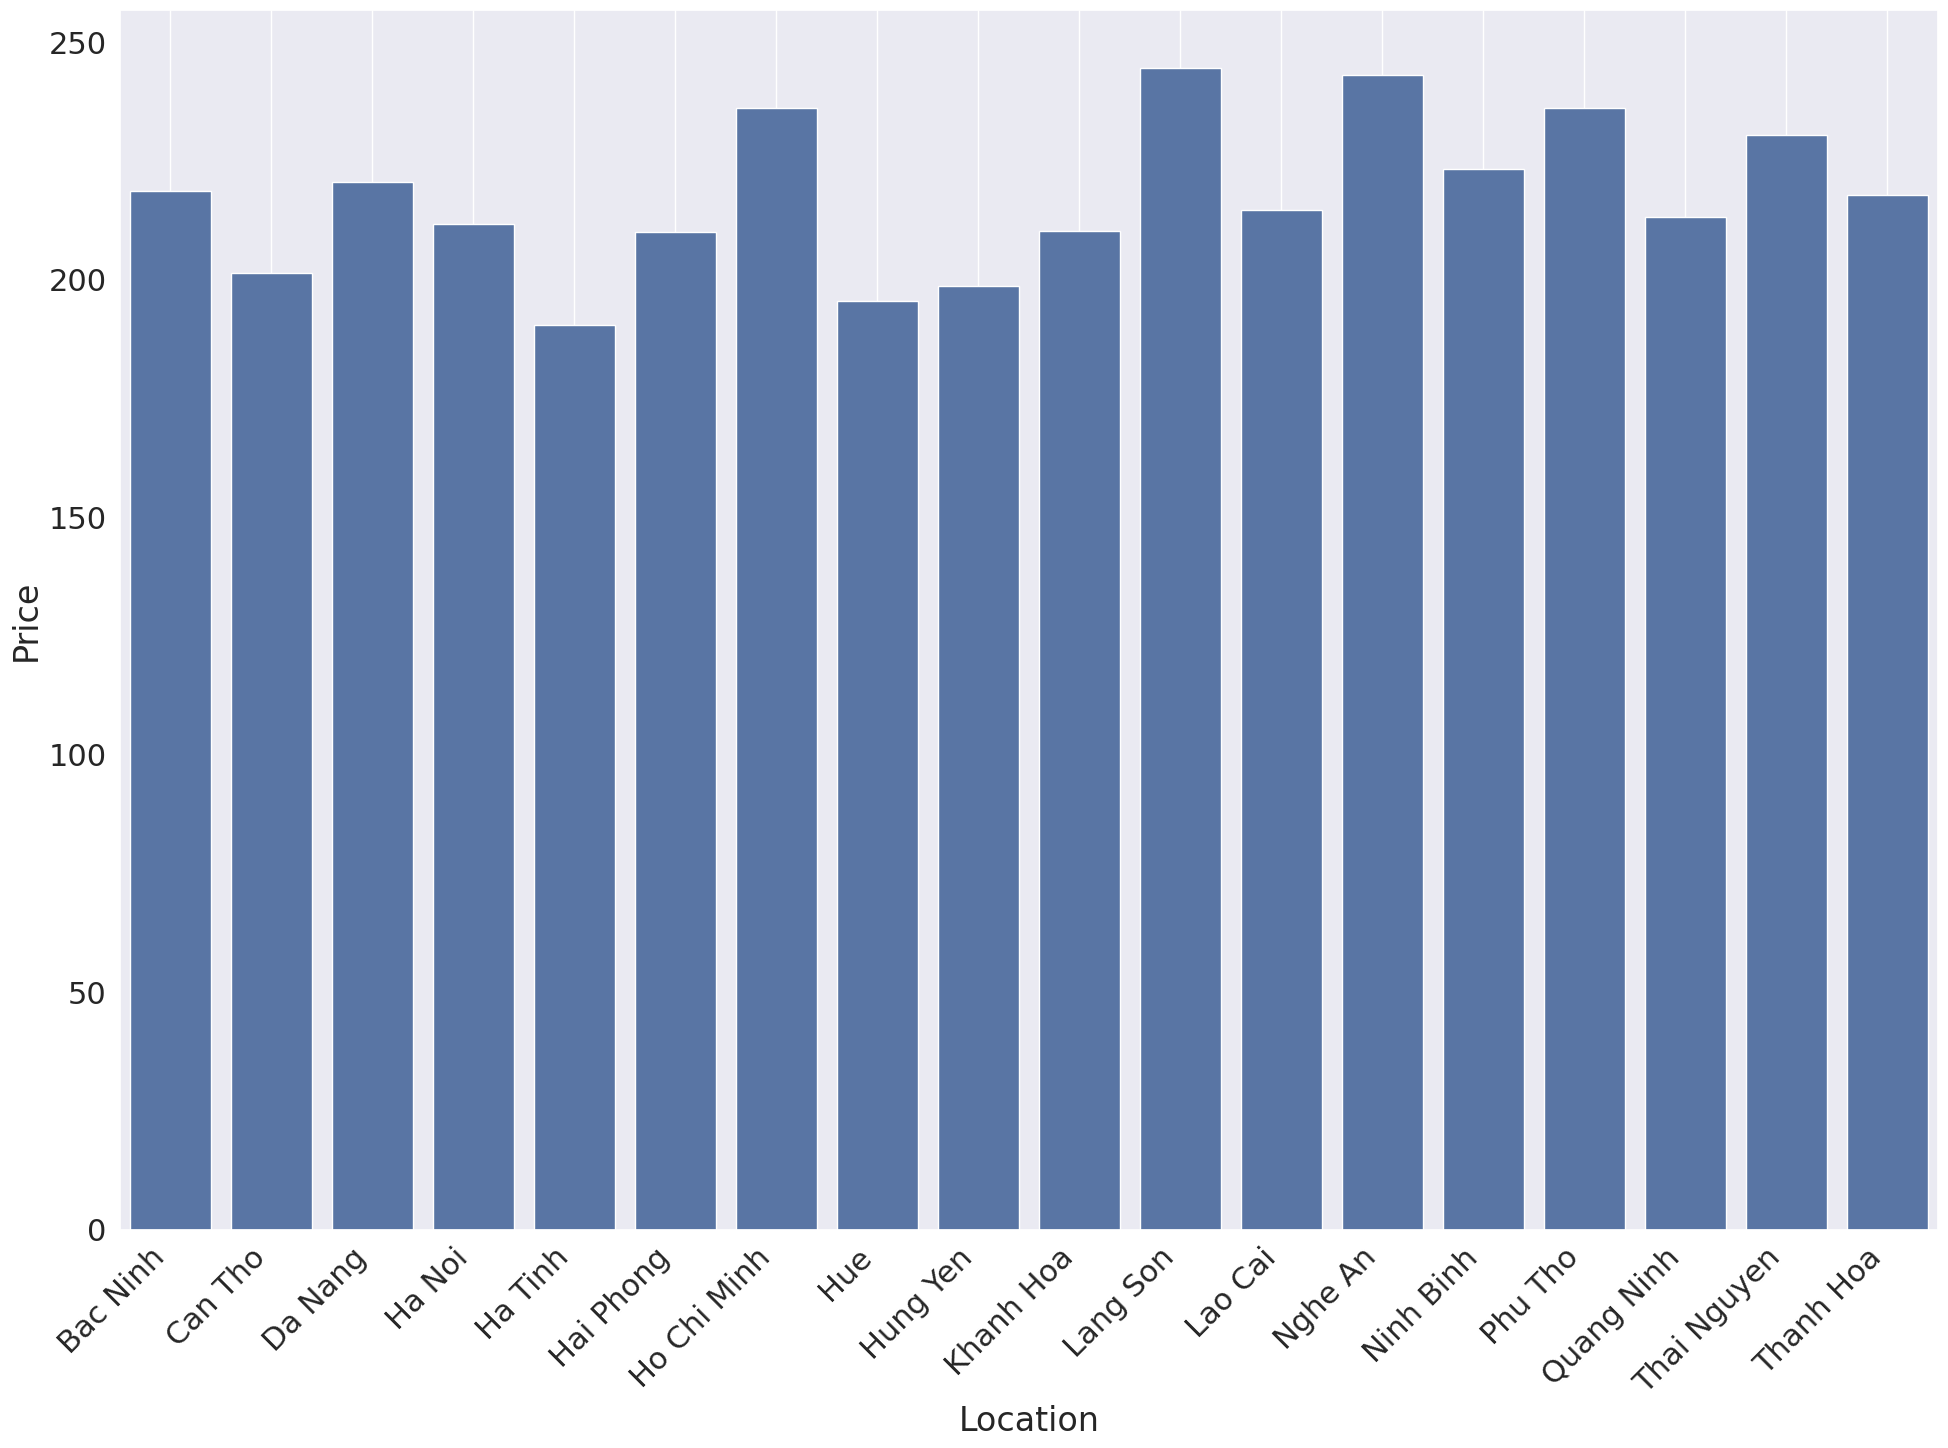

In [ ]:
# Price vs Location
plt.figure(figsize=(20, 15))
sns.set(font_scale=2)
ax = sns.barplot(x='Location', y='Price', data=cars, ci=None)

# rotate X label
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.grid()
plt.tight_layout()
plt.show()


#### Price Vs Brand

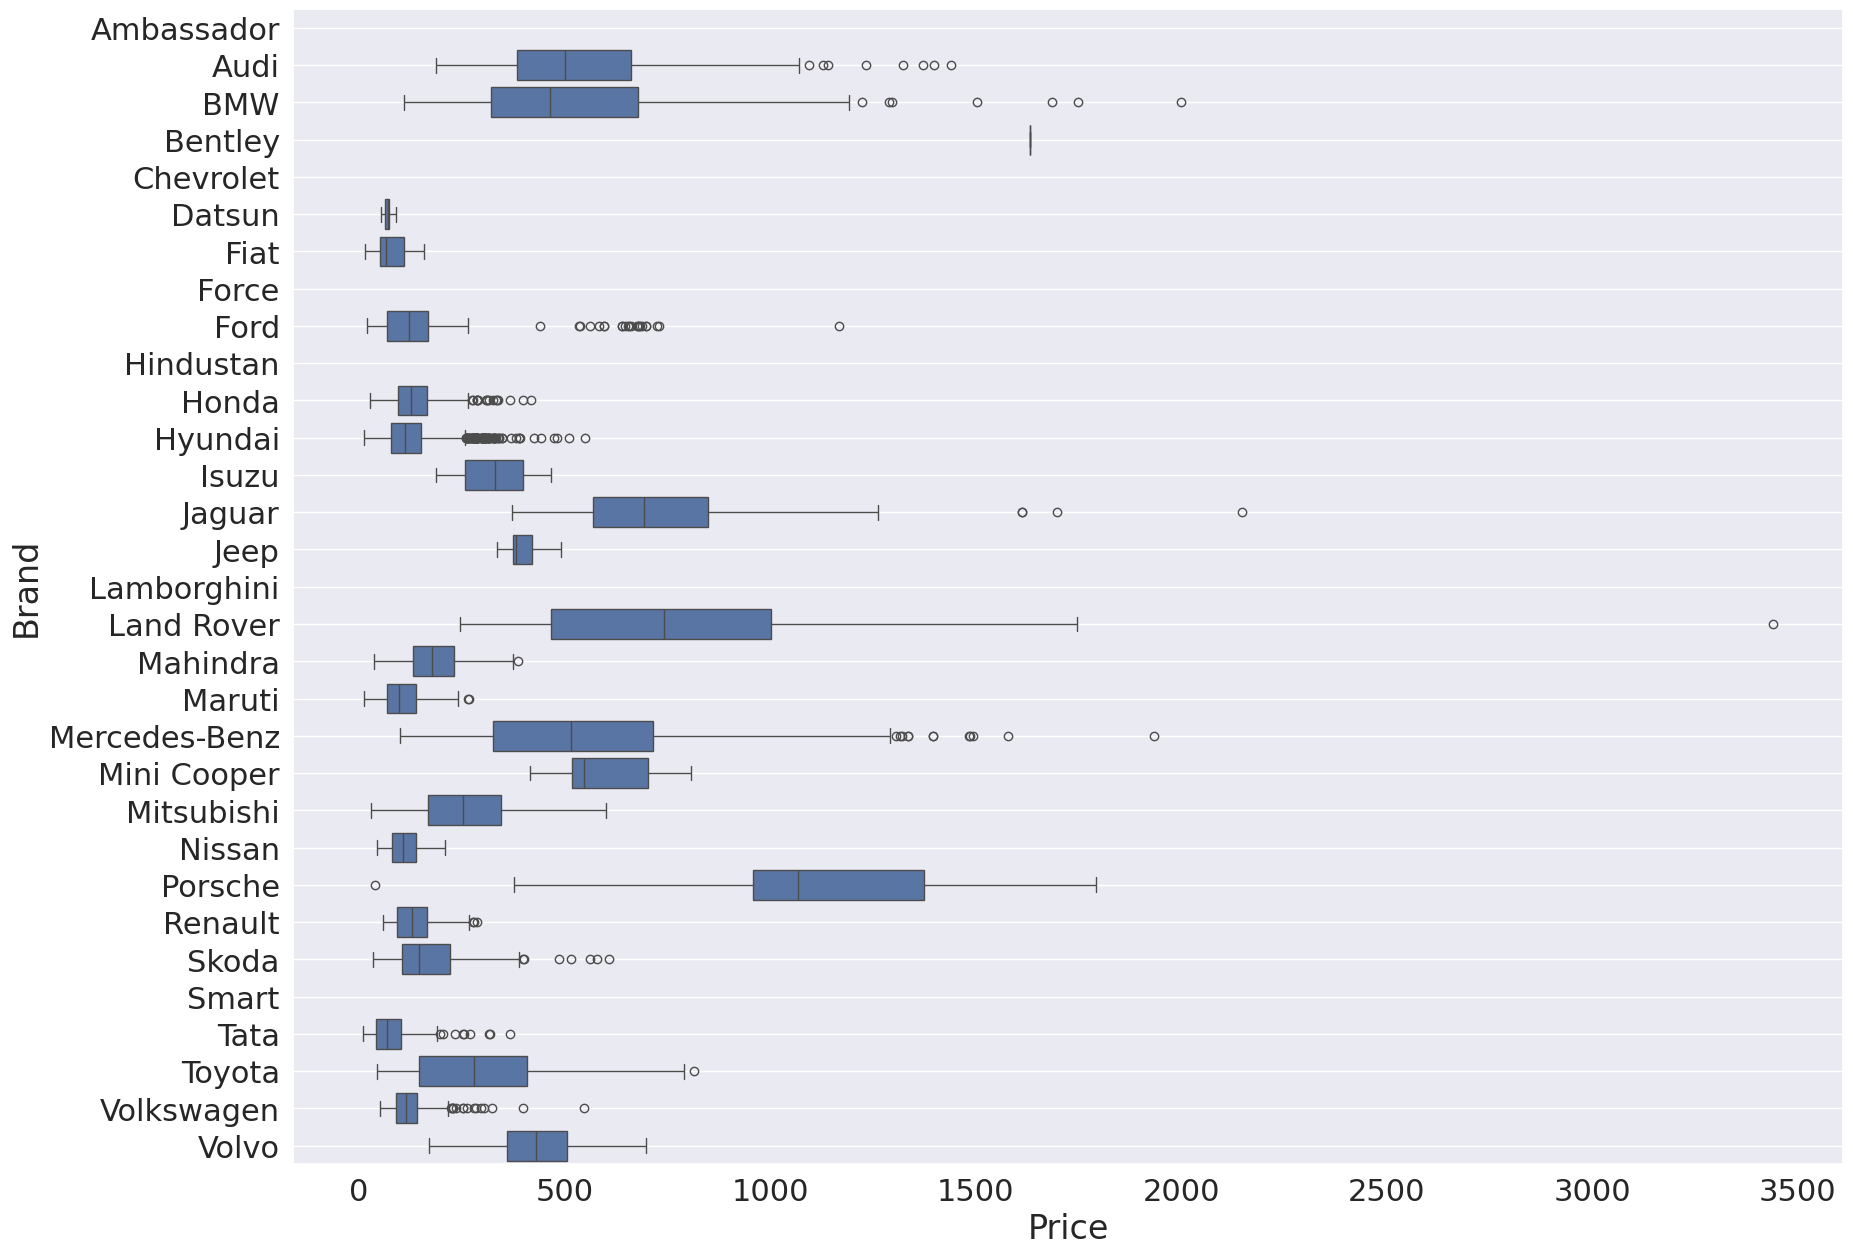

In [ ]:
#Price and band
plt.figure(figsize=(20,15))
sns.set(font_scale=2)
sns.boxplot(x='Price', y='Brand', data=cars)
plt.grid()

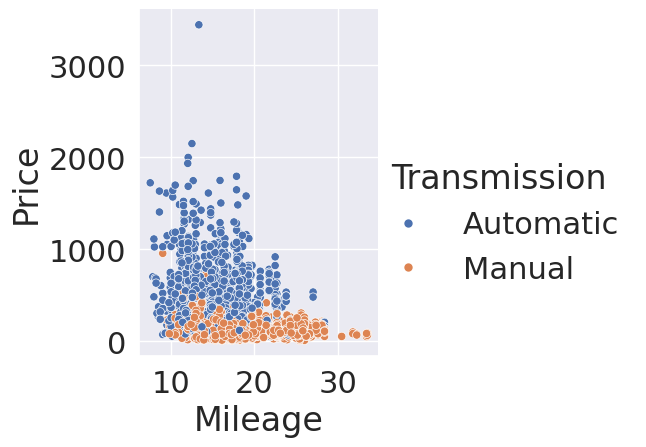

In [ ]:
sns.relplot(data=cars, y='Price',x='Mileage',hue='Transmission',aspect=1,height=5)

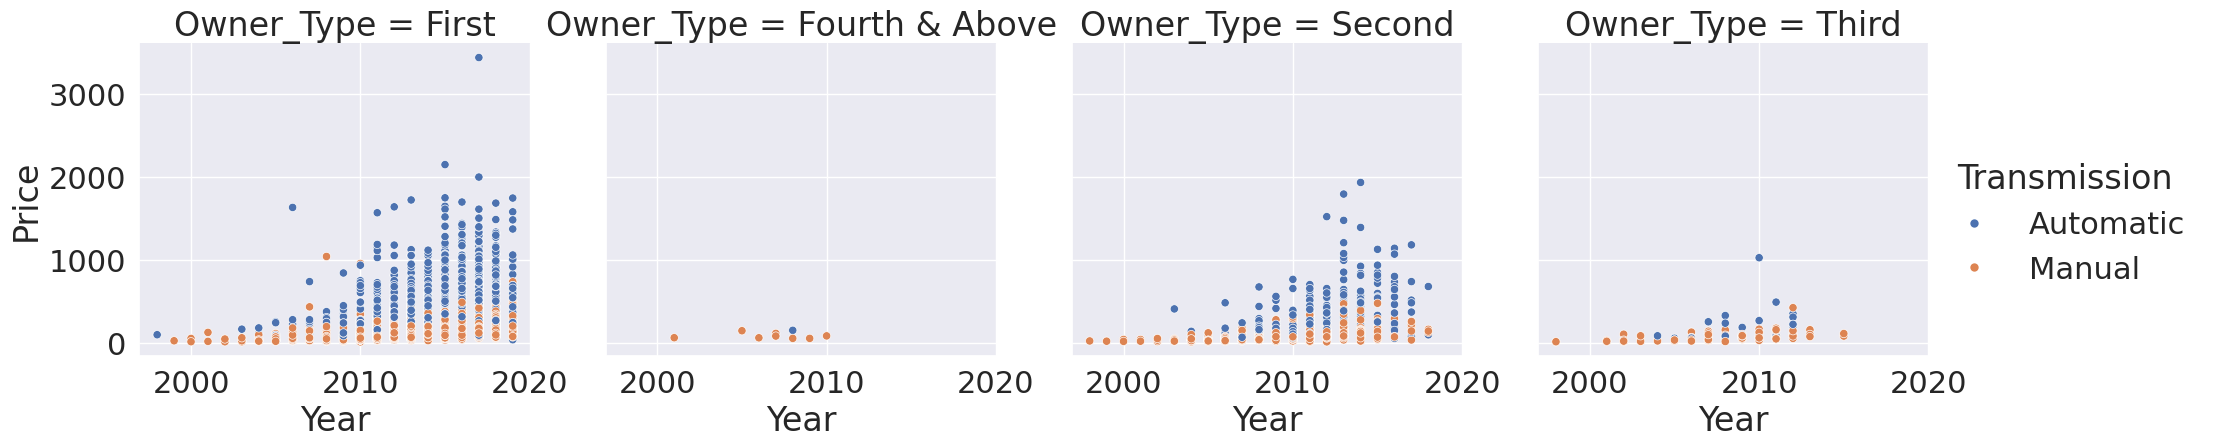

In [ ]:
sns.relplot(data=cars, y='Price',x='Year',col='Owner_Type',hue='Transmission',aspect=1,height=5)

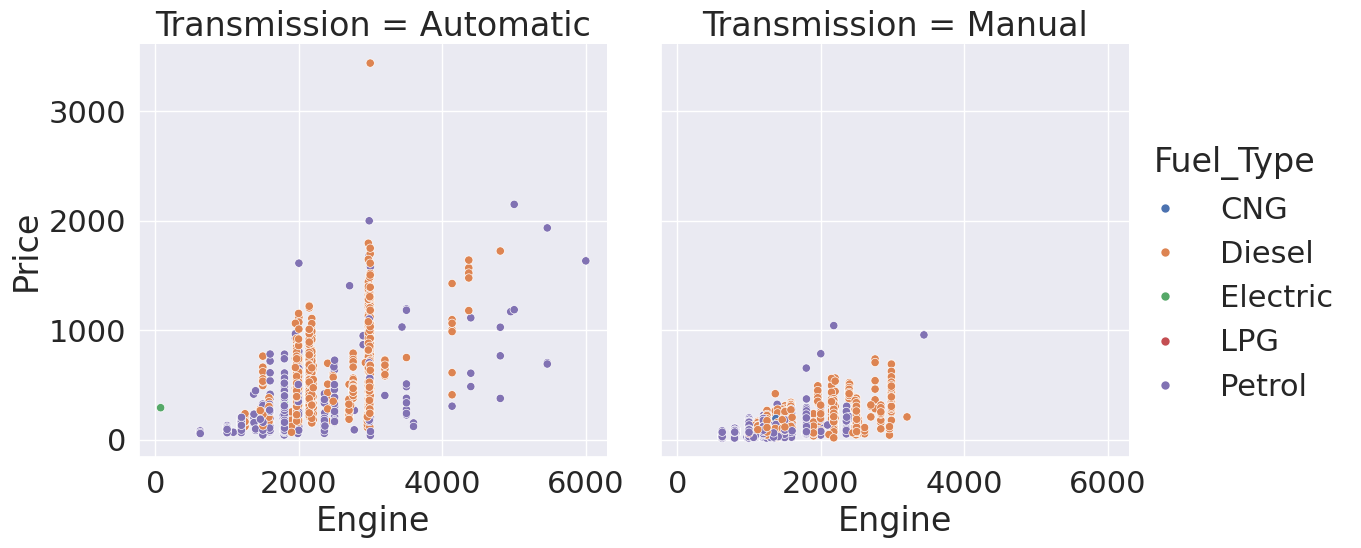

In [ ]:
sns.relplot(data=cars, y='Price',x='Engine',col='Transmission',aspect=1,height=6,hue="Fuel_Type")

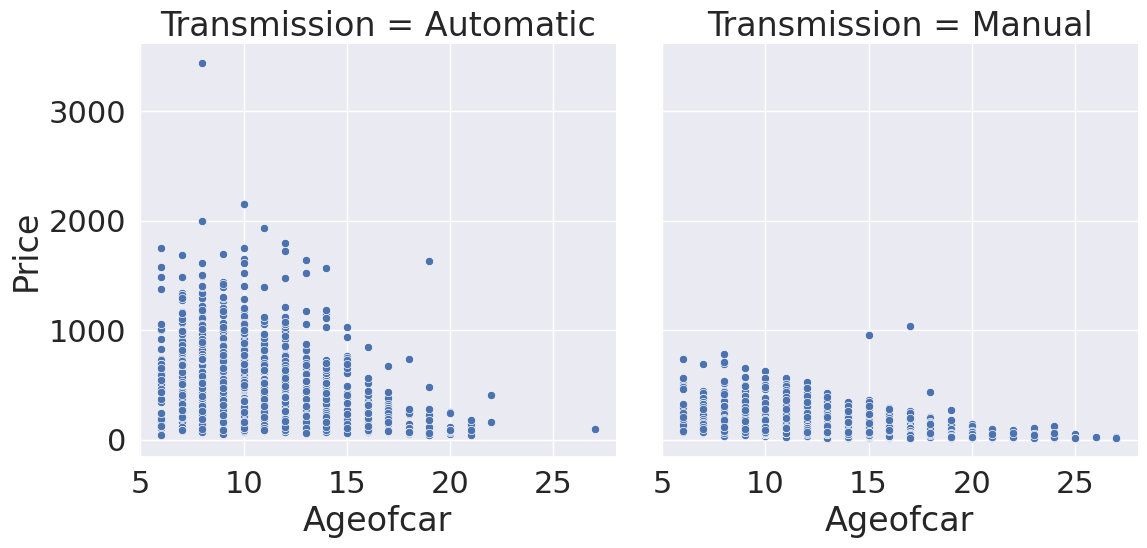

In [ ]:

sns.relplot(data=cars, y='Price',x='Ageofcar',col='Transmission',aspect=1,height=6)

# Insights based on EDA

<p style = "font-size : 20px ; color: blue;font-family:TimesNewRoman">
<b>Observations</b>
</p>


Xe đắt chủ yếu ở Lang Son, Nghe An, HCM.

Xe 2 chỗ thường đắt hơn.

Xe dùng nhiên liệu Diesel đắt hơn so với các loại nhiên liệu khác.

Đúng như kỳ vọng, mẫu xe đời cũ được bán rẻ hơn so với đời mới.

Xe số tự động có giá cao hơn xe số sàn.

Xe có dung tích động cơ lớn thì giá cao hơn.

Giá giảm khi số đời chủ sở hữu tăng.

Xe số tự động thường cần động cơ và công suất cao hơn.

Giá xe Diesel đã tăng ở các mẫu gần đây.

Engine, Power, Age of car, Mileage, Fuel type, Location, Tranmission đều ảnh hưởng đến giá.

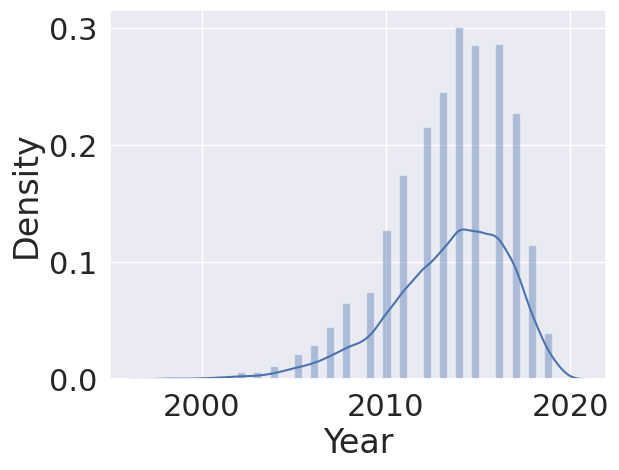

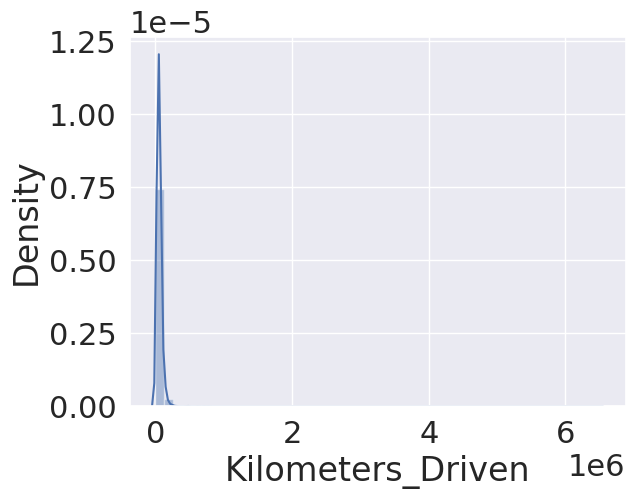

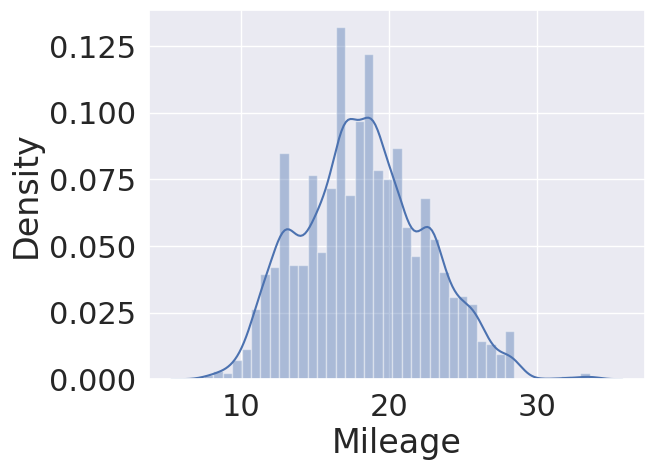

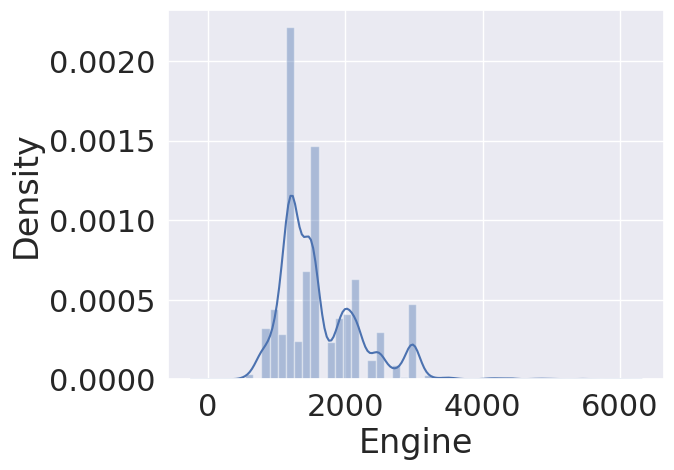

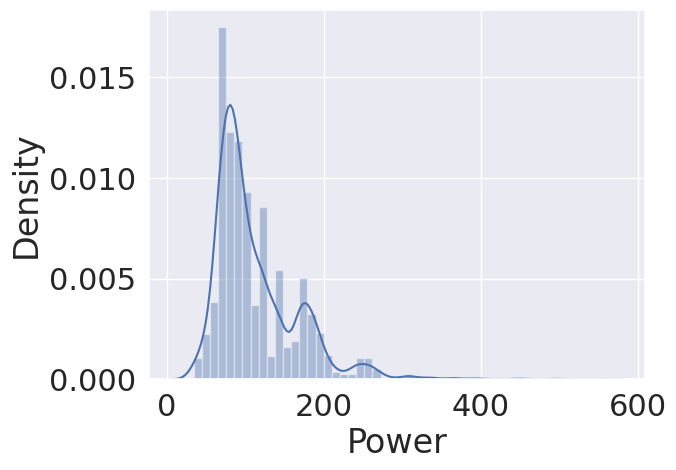

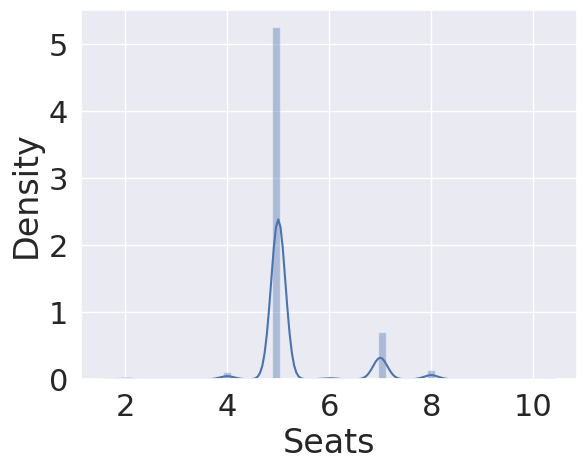

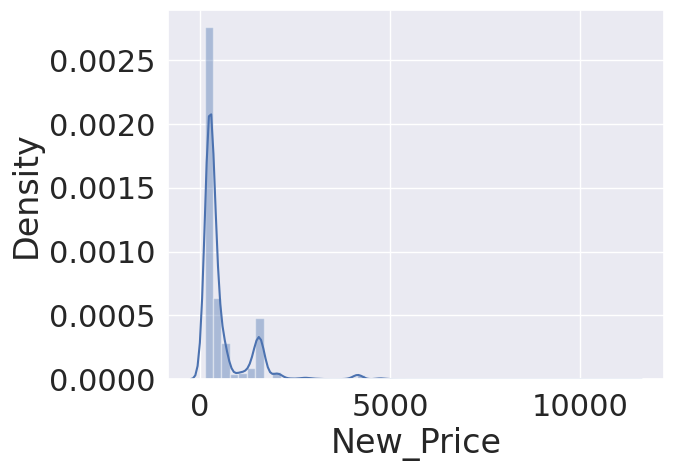

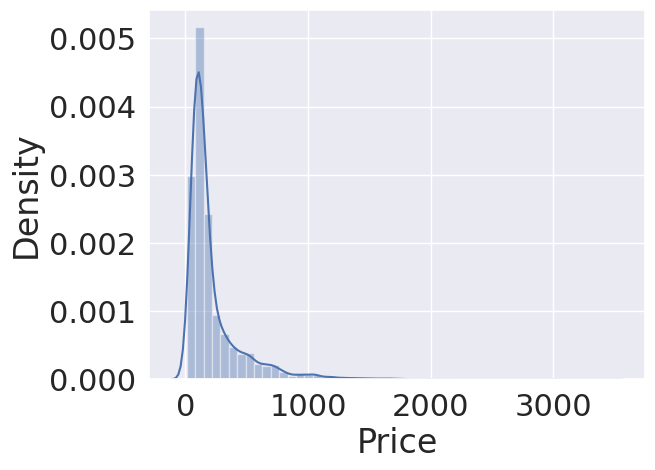

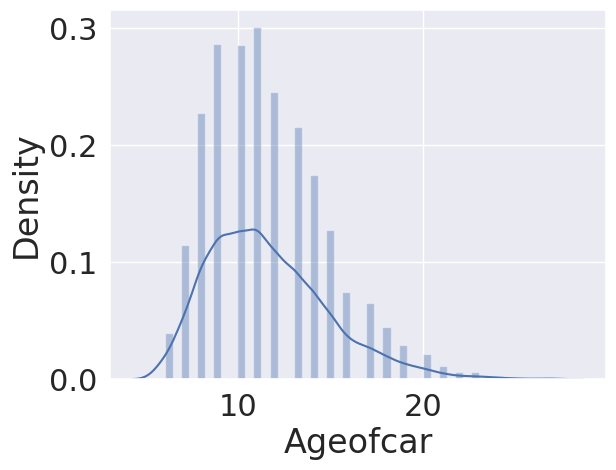

In [ ]:
# check distrubution if skewed. If distrubution is skewed , it is advice to use log transform
cols_to_log = cars.select_dtypes(include=np.number).columns.tolist()
for colname in cols_to_log:
    sns.distplot(cars[colname], kde=True)
    plt.show()

Phân phối bị lệch phải, sử dụng phép biến đổi Log có thể giúp chuẩn hóa

In [ ]:
def Perform_log_transform(df,col_log):
    """#Perform Log Transformation of dataframe , and list of columns """
    for colname in col_log:
        df[colname + '_log'] = np.log(df[colname])
    #df.drop(col_log, axis=1, inplace=True)
    df.info()

In [ ]:
#This needs to be done before the data is split
Perform_log_transform(cars,['Kilometers_Driven','Price'])

<class 'pandas.core.frame.DataFrame'>
Index: 5892 entries, 0 to 6017
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Name                   5892 non-null   object  
 1   Location               5892 non-null   category
 2   Year                   5892 non-null   int64   
 3   Kilometers_Driven      5892 non-null   int64   
 4   Fuel_Type              5892 non-null   category
 5   Transmission           5892 non-null   category
 6   Owner_Type             5892 non-null   category
 7   Mileage                5892 non-null   float64 
 8   Engine                 5892 non-null   int64   
 9   Power                  5892 non-null   float64 
 10  Seats                  5892 non-null   float64 
 11  New_Price              5892 non-null   float64 
 12  Price                  5892 non-null   float64 
 13  Ageofcar               5892 non-null   int64   
 14  Brand                  5892 non-null   catego

In [ ]:
cars

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Ageofcar,Brand,Model,Brand_Class,Kilometers_Driven_log,Price_log
S.No.,,,,,,,,,,,,,,,,,,,
0,Maruti Wagon R LXI CNG,Ha Noi,2010,72000,CNG,Manual,First,26.60000,998,58.16000,5.00000,158.70000,45.00000,15,Maruti,WagonR,Low,11.18442,3.80666
1,Hyundai Creta 1.6 CRDi SX Option,Lao Cai,2015,41000,Diesel,Manual,First,19.67000,1582,126.20000,5.00000,481.80000,299.00000,10,Hyundai,Creta1.6,Mid,10.62133,5.70044
2,Honda Jazz V,Ha Noi,2011,46000,Petrol,Manual,First,18.20000,1199,88.70000,5.00000,258.30000,122.00000,14,Honda,JazzV,Mid,10.73640,4.80402
3,Maruti Ertiga VDI,Ha Noi,2012,87000,Diesel,Manual,First,20.77000,1248,88.76000,7.00000,338.10000,147.00000,13,Maruti,ErtigaVDI,Low,11.37366,4.99043
4,Audi A4 New 2.0 TDI Multitronic,Lang Son,2013,40670,Diesel,Automatic,Second,15.20000,1968,140.80000,5.00000,1594.20000,416.00000,12,Audi,A4New,High,10.61325,6.03069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6013,Honda Amaze VX i-DTEC,Ha Noi,2015,70602,Diesel,Manual,First,25.80000,1498,98.60000,5.00000,289.95000,116.00000,10,Honda,AmazeVX,Mid,11.16481,4.75359
6014,Maruti Swift VDI,Phu Tho,2014,27365,Diesel,Manual,First,28.40000,1248,74.00000,5.00000,236.40000,111.00000,11,Maruti,SwiftVDI,Low,10.21702,4.70953
6015,Hyundai Xcent 1.1 CRDi S,Bac Ninh,2015,100000,Diesel,Manual,First,24.40000,1120,71.00000,5.00000,246.90000,92.00000,10,Hyundai,Xcent1.1,Mid,11.51293,4.52179


In [ ]:
# cars.to_excel("output.xlsx", index=False)

In [ ]:

cars.drop(['Name','Model','Year','Brand','New_Price'],axis=1,inplace=True)

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5892 entries, 0 to 6017
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Location               5892 non-null   category
 1   Kilometers_Driven      5892 non-null   int64   
 2   Fuel_Type              5892 non-null   category
 3   Transmission           5892 non-null   category
 4   Owner_Type             5892 non-null   category
 5   Mileage                5892 non-null   float64 
 6   Engine                 5892 non-null   int64   
 7   Power                  5892 non-null   float64 
 8   Seats                  5892 non-null   float64 
 9   Price                  5892 non-null   float64 
 10  Ageofcar               5892 non-null   int64   
 11  Brand_Class            5892 non-null   category
 12  Kilometers_Driven_log  5892 non-null   float64 
 13  Price_log              5892 non-null   float64 
dtypes: category(5), float64(6), int64(3)
memory u

# Model Building

In [ ]:
X = cars.drop(["Price", "Price_log"], axis=1)
y = cars[["Price_log", "Price"]]

### Creating dummy variables

In [ ]:
def encode_cat_vars(x):
    x = pd.get_dummies(
        x,
        columns=x.select_dtypes(include=["object", "category"]).columns.tolist(),
        drop_first=True,
    )
    return x

In [ ]:
#Dummy variable creation is done before spliting the data , so all the different categories are covered
#create dummy variable
X = encode_cat_vars(X)
X.head()

,Kilometers_Driven,Mileage,Engine,Power,Seats,Ageofcar,Kilometers_Driven_log,Location_Can Tho,Location_Da Nang,Location_Ha Noi,...,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third,Brand_Class_Low,Brand_Class_Mid
S.No.,,,,,,,,,,,,,,,,,,,,,
0,72000,26.60000,998,58.16000,5.00000,15,11.18442,False,False,True,...,False,False,False,False,True,False,False,False,True,False
1,41000,19.67000,1582,126.20000,5.00000,10,10.62133,False,False,False,...,True,False,False,False,True,False,False,False,False,True
2,46000,18.20000,1199,88.70000,5.00000,14,10.73640,False,False,True,...,False,False,False,True,True,False,False,False,False,True
3,87000,20.77000,1248,88.76000,7.00000,13,11.37366,False,False,True,...,True,False,False,False,True,False,False,False,True,False
4,40670,15.20000,1968,140.80000,5.00000,12,10.61325,False,False,False,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.reset_index()
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

X_train: (4124, 34)
X_test: (1768, 34)
y_train: (4124, 2)
y_test: (1768, 2)


In [ ]:
# Statsmodel api does not add a constant by default. We need to add it explicitly.
X_train = sm.add_constant(X_train).astype('float64')
# Add constant to test data
X_test = sm.add_constant(X_test)


def build_ols_model(train):
    # Create the model
    olsmodel = sm.OLS(y_train["Price_log"], train)
    return olsmodel.fit()

In [ ]:
#fit statmodel
olsmodel1 = build_ols_model(X_train)
print(olsmodel1.summary())

                            OLS Regression Results                            
Dep. Variable:              Price_log   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     865.1
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        09:41:35   Log-Likelihood:                -688.55
No. Observations:                4124   AIC:                             1447.
Df Residuals:                    4089   BIC:                             1668.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 


    
Cả R-squared và Adjusted R-squared của mô hình đều rất cao. Đây là một dấu hiệu rõ ràng cho thấy chúng ta đã xây dựng được một mô hình tốt, có thể giải thích được đến 88% sự biến thiên trong giá xe đã qua sử dụng.

Mô hình không phải là underfitting cũng không phải là overfitting.

Để có thể đưa ra các suy luận thống kê từ mô hình, chúng ta cần kiểm định rằng các giả định của hồi quy tuyến tính được tuân thủ.

Trước khi tiến hành kiểm định giả định, chúng ta sẽ thực hiện một bước kiểm tra nhanh về hiệu suất của mô hình trên dữ liệu kiểm thử.

In [ ]:
import math

# RMSE
def rmse(predictions, targets):
    return np.sqrt(((targets - predictions) ** 2).mean())


# MAPE
def mape(predictions, targets):
    return np.mean(np.abs((targets - predictions)) / targets) * 100


# MAE
def mae(predictions, targets):
    return np.mean(np.abs((targets - predictions)))


# Model Performance on test and train data
def model_pref(olsmodel, x_train, x_test):

    # Insample Prediction
    y_pred_train_pricelog = olsmodel.predict(x_train)
    y_pred_train_Price = y_pred_train_pricelog.apply(math.exp)
    y_train_Price = y_train["Price"]

    # Prediction on test data
    y_pred_test_pricelog = olsmodel.predict(x_test)
    y_pred_test_Price = y_pred_test_pricelog.apply(math.exp)
    y_test_Price = y_test["Price"]

    print(
        pd.DataFrame(
            {
                "Data": ["Train", "Test"],
                "RMSE": [
                    rmse(y_pred_train_Price, y_train_Price),
                    rmse(y_pred_test_Price, y_test_Price),
                ],
                "MAE": [
                    mae(y_pred_train_Price, y_train_Price),
                    mae(y_pred_test_Price, y_test_Price),
                ],
                "MAPE": [
                    mape(y_pred_train_Price, y_train_Price),
                    mape(y_pred_test_Price, y_test_Price),
                ],
            }
        )
    )


# Checking model performance
model_pref(olsmodel1, X_train, X_test)  # High Overfitting.

    Data      RMSE      MAE     MAPE
0  Train 110.39337 48.89405 23.74371
1   Test 116.02300 48.68516 23.09080


   
Sai số bình phương trung bình gốc (RMSE) của dữ liệu train và test không khác nhau, cho thấy mô hình của chúng ta không bị overfitting trên dữ liệu huấn luyện.

Sai số tuyệt đối trung bình (MAE) cho thấy mô hình hiện tại có thể dự đoán giá xe đã qua sử dụng với sai số trung bình khoảng 75 triệu VND trên dữ liệu test.

Đơn vị của cả RMSE và MAE đều giống nhau – trong trường hợp này là triệu VND. Tuy nhiên, RMSE lớn hơn MAE vì nó phạt (penalize) mạnh hơn với các giá trị ngoại lai.

Sai số phần trăm tuyệt đối trung bình (MAPE) trên dữ liệu test vào khoảng ~23%.

# Test Assumptions

## Kiểm tra các giả định của hồi quy tuyến tính

1. Không có đa cộng tuyến (No Multicollinearity)

2. Trung bình của phần dư phải bằng 0 (Mean of residuals = 0)

3. Không có hiện tượng phương sai thay đổi (No Heteroscedasticity)

4. Tính tuyến tính của các biến (Linearity of variables)

5. Phân phối chuẩn của sai số (Normality of error terms)

### Kiểm tra Giả định 1: Không có đa cộng tuyến

Chúng ta sẽ sử dụng chỉ số VIF để kiểm tra xem dữ liệu có đa cộng tuyến hay không.

Các biến có điểm VIF > 5 sẽ được loại bỏ hoặc xử lý cho đến khi tất cả các biến đều có điểm VIF < 5.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def checking_vif(train):
    vif = pd.DataFrame()
    vif["feature"] = train.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(train.values, i) for i in range(len(train.columns))
    ]
    return vif


In [ ]:
# Check VIF
print(checking_vif(X_train))

                      feature        VIF
0                       const 1040.51234
1           Kilometers_Driven    2.85224
2                     Mileage    3.44640
3                      Engine    9.20314
4                       Power    7.92842
5                       Seats    2.19189
6                    Ageofcar    1.87871
7       Kilometers_Driven_log    3.21974
8            Location_Can Tho    2.01906
9            Location_Da Nang    3.03768
10            Location_Ha Noi    8.48670
11           Location_Ha Tinh    2.14670
12         Location_Hai Phong    3.05974
13       Location_Ho Chi Minh    5.51726
14               Location_Hue    2.08196
15          Location_Hung Yen    2.02408
16         Location_Khanh Hoa    1.96291
17          Location_Lang Son    2.01952
18           Location_Lao Cai    2.10322
19           Location_Nghe An    2.07650
20         Location_Ninh Binh    2.03373
21           Location_Phu Tho    2.06771
22        Location_Quang Ninh    2.05128
23       Locatio

Bây giờ ta sẽ loại bỏ hiện tượng đa cộng tuyến khỏi mô hình. Các biến Engine, Power, Fuel_type có mức đa cộng tuyến cao. Tuy nhiên, Fuel_type là một biến quan trọng trong việc dự đoán của mô hình, vì vậy chúng ta sẽ loại bỏ biến Engine.

In [ ]:
X_train1=X_train.drop(['Engine'],axis=1)
X_test1=X_test.drop(['Engine'],axis=1)
olsmodel2= build_ols_model(X_train1)

print(olsmodel2.summary())

# Checking model performance
model_pref(olsmodel2, X_train1, X_test1)

                            OLS Regression Results                            
Dep. Variable:              Price_log   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     859.4
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        09:41:36   Log-Likelihood:                -754.86
No. Observations:                4124   AIC:                             1578.
Df Residuals:                    4090   BIC:                             1793.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [ ]:
print(checking_vif(X_train1))

                      feature        VIF
0                       const 1018.47441
1           Kilometers_Driven    2.83650
2                     Mileage    2.87641
3                       Power    3.64036
4                       Seats    1.90813
5                    Ageofcar    1.87035
6       Kilometers_Driven_log    3.21021
7            Location_Can Tho    2.01901
8            Location_Da Nang    3.03730
9             Location_Ha Noi    8.48661
10           Location_Ha Tinh    2.14417
11         Location_Hai Phong    3.05973
12       Location_Ho Chi Minh    5.51716
13               Location_Hue    2.08191
14          Location_Hung Yen    2.02406
15         Location_Khanh Hoa    1.96262
16          Location_Lang Son    2.01847
17           Location_Lao Cai    2.10321
18           Location_Nghe An    2.07628
19         Location_Ninh Binh    2.03336
20           Location_Phu Tho    2.06760
21        Location_Quang Ninh    2.05127
22       Location_Thai Nguyen    2.03434
23         Locat


Chúng ta đã loại bỏ hiện tượng đa cộng tuyến khỏi dữ liệu. Các biến Fuel_Type đang cho thấy chỉ số VIF cao vì hầu hết xe đều chạy bằng diesel hoặc xăng, do đó hai đặc trưng này có mối tương quan với nhau.

Chúng ta sẽ không loại bỏ biến này khỏi mô hình vì điều đó sẽ không ảnh hưởng đến việc diễn giải các đặc trưng khác trong mô hình.

### Kiểm tra giả định 2: Trung bình của phần dư phải bằng 0 (Mean of residuals = 0)

In [ ]:
residuals = olsmodel2.resid
np.mean(residuals)

np.float64(2.2940485592622813e-12)

Trung bình của phần dư rất gần bằng 0. Như vậy, giả định thứ hai cũng đã được thỏa mãn.

### Kiểm tra Giả định 3: Không có hiện tượng dị biệt phương sai


* Homoscedasticity (phương sai đồng nhất) – Nếu phần dư được phân bố đối xứng quanh đường hồi quy, thì dữ liệu được xem là có phương sai đồng nhất.

* Heteroscedasticity (phương sai thay đổi) – Nếu phần dư không được phân bố đối xứng quanh đường hồi quy, thì dữ liệu được xem là có phương sai thay đổi. Trong trường hợp này, phần dư có thể tạo thành hình phễu hoặc một dạng không đối xứng khác.

Chúng ta sẽ sử dụng kiểm định Goldfeld-Quandt để kiểm tra giả thuyết sau:

Giả thuyết không (H0): Phần dư có phương sai đồng nhất (Homoscedastic).

Giả thuyết đối (H1): Phần dư có phương sai thay đổi (Heteroscedasticity).

Mức ý nghĩa: α = 0.05

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(residuals, X_train1)
lzip(name, test)

[('F statistic', np.float64(0.8710022806329011)),
 ('p-value', np.float64(0.9990600508129559))]


    
Vì p-value > 0.05, chúng ta không thể bác bỏ giả thuyết không rằng phần dư có phương sai đồng nhất.

Như vậy, giả định 3 cũng đã được thỏa mãn đối với mô hình olsmodel2.

### Kiểm tra Giả định 4: Tính tuyến tính của các biến

Các biến độc lập phải có mối quan hệ tuyến tính với biến phụ thuộc.

Để kiểm tra giả định này, chúng ta sẽ vẽ đồ thị giữa phần dư (residuals) và giá trị dự đoán (fitted values), và đảm bảo rằng phần dư không tạo thành một mẫu hình rõ ràng nào. Chúng phải được phân tán ngẫu nhiên và đồng đều trên trục X.

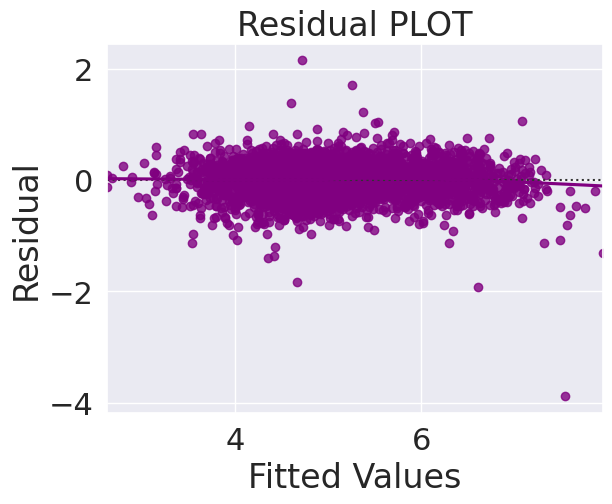

In [ ]:
# predicted values
fitted = olsmodel2.fittedvalues

# sns.set_style("whitegrid")
sns.residplot(x=fitted, y=residuals, color="purple", lowess=True)
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual PLOT")
plt.show()

Giả định 4 đã được thỏa mãn bởi mô hình olsmodel2. Trên đồ thị giữa phần dư và giá trị dự đoán không xuất hiện bất kỳ mẫu hình nào.

### Kiểm tra Giả định 5: Phân phối chuẩn của sai số

Các phần dư cần tuân theo phân phối chuẩn.

<Axes: ylabel='Density'>

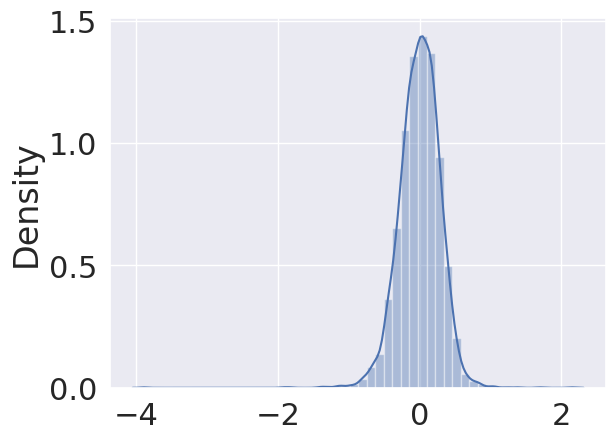

In [ ]:
sns.distplot(residuals)

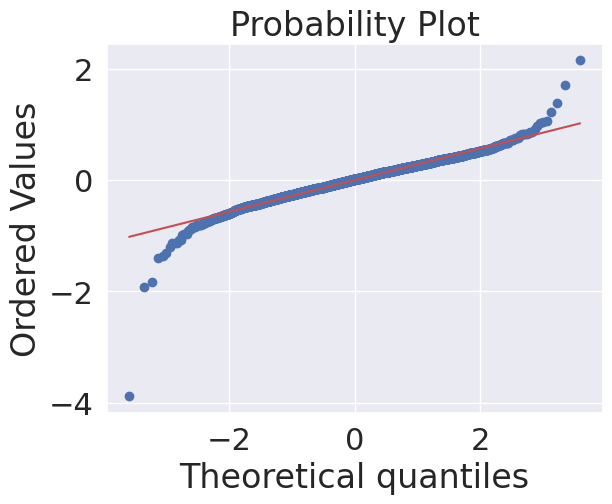

In [ ]:
# Plot q-q plot of residuals
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
plt.show()

Các phần dư có phân phối gần chuẩn. Như vậy, giả định 5 cũng đã được thỏa mãn.
Tuy nhiên, chúng ta cần xem xét kỹ hơn các giá trị ở phần đuôi phân phối, nơi xuất hiện các sai số dư lớn.

Bây giờ, khi đã thấy rằng **olsmodel2** tuân thủ tất cả các giả định của hồi quy tuyến tính, chúng ta có thể sử dụng mô hình này để rút ra các suy luận.


In [ ]:
print(olsmodel2.summary())
# Checking model performance
model_pref(olsmodel2, X_train1, X_test1)

                            OLS Regression Results                            
Dep. Variable:              Price_log   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     859.4
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        09:41:38   Log-Likelihood:                -754.86
No. Observations:                4124   AIC:                             1578.
Df Residuals:                    4090   BIC:                             1793.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

## Observations from the model



    
 **Cần lưu ý rằng các giá trị dự đoán ở đây là log(price), do đó các hệ số cần được chuyển đổi tương ứng để hiểu rõ ảnh hưởng của chúng đến giá**

1. Với mô hình hồi quy tuyến tính, chúng ta đã giải thích được khoảng ~89% sự biến thiên trong dữ liệu.
    
2. Mô hình cho thấy các yếu tố dự báo quan trọng nhất ảnh hưởng đến giá xe đã qua sử dụng là:
    - Age of the car
    - Number of seats in the car
    - Power of the engine
    - Mileage
    - Kilometers Driven
    - Location
    - Fuel_Type
    - OwnerType
    - Transmission - Automatic/Manual
        
3. Những chiếc xe mới hơn thường bán được giá cao hơn. Mỗi 1 đơn vị tăng trong tuổi đời xe sẽ dẫn đến mức giảm giá khoảng exp(3.360) = 33.6 triệu VND , khi các yếu tố khác giữ nguyên.


4. Khi số ghế ngồi tăng, giá xe cũng tăng.
    
5. Mức tiêu thụ nhiên liệu (Mileage) có mối quan hệ nghịch với giá xe. Thông thường, xe có mức tiêu thụ nhiên liệu cao thường là các dòng xe giá rẻ.
    
6. Số km đã đi có mối quan hệ âm với giá xe, điều này là trực quan. Xe chạy nhiều km hơn sẽ bị hao mòn nhiều hơn và do đó bán với giá thấp hơn, khi các yếu tố khác giữ nguyên.
    
7. Các biến phân loại (categorical variables) khó diễn giải hơn một chút. Tuy nhiên có thể thấy rằng tất cả các biến liên quan đến car_category trong bộ dữ liệu đều có mối quan hệ âm với giá xe, và mức độ ảnh hưởng âm này giảm dần khi thương hiệu xe thuộc nhóm thấp hơn.

# Recommendations

* Mô hình Hồi quy tuyến tính cuối cùng của chúng ta có MAPE = 23% trên dữ liệu kiểm thử, nghĩa là chúng ta có thể dự đoán trong phạm vi sai số khoảng 23% so với giá trị thực tế. Đây là một mô hình khá tốt, nhưng vẫn có thể cải thiện thêm.

* Dựa trên phân tích, chúng ta có thể chia xe thành 3 phân khúc: thấp, trung bình và cao cấp.

* Các thương hiệu như Maruti, Hyundai, Honda thuộc phân khúc giá thấp và rất phổ biến trên thị trường xe đã qua sử dụng.

* Các thương hiệu như BMW, Bentley, Jaguar, Land Rover, Mercedes Benz, Porsche, Mini Cooper thuộc phân khúc cao cấp và thường được mua bởi những người đam mê xe, sẵn sàng mua cả những chiếc xe đã qua tay nhiều chủ với mức giá cao.

* Hà Nội và TP. Hồ Chí Minh có vẻ phổ biến hơn trong thị trường xe đã qua sử dụng, nhưng cần xác minh thêm bằng dữ liệu từ các khu vực nhân khẩu học khác. Bước tiếp theo sau đó là tiến hành phân cụm dữ liệu để xem có cần xây dựng nhiều mô hình riêng cho từng địa điểm/loại xe hay không.

* Cần tăng số lượng xe số tự động, vì loại xe này thường bán được giá cao hơn, giúp tăng lợi nhuận.

* Khi giá xăng tăng, xe chạy dầu diesel có nhu cầu cao hơn trong những năm gần đây. Việc mua vào và bán lại có thể mang lại lợi nhuận lớn.

* Ngoài ra, có thể đưa ra các chính sách khuyến khích như: cho khách hàng lái thử nửa ngày để tăng khả năng mua.

* Có thể cung cấp gói bảo dưỡng xe, trong đó khách hàng trả một khoản phí nhỏ ban đầu và có thể mang xe đi bảo dưỡng bất kỳ lúc nào trong năm để thu hút thêm khách hàng.
    
  
<b>Important points</b>
* Còn có nhiều yếu tố mềm khác cũng cần được xem xét khi mua xe, chẳng hạn như mức độ hao mòn mà chiếc xe đã trải qua và chi phí công ty phải bỏ ra để sửa chữa, làm mới xe trước khi bán.

* Nếu xe đã từng gặp tai nạn, điều đó cũng sẽ ảnh hưởng đến giá bán.

* Các tính năng tiện ích như điều hòa (AC), cửa sổ trời (Moon roof), túi khí (Airbags) cũng có thể tác động đến giá.

* Những mẫu xe quá cũ sẽ bị khấu hao mạnh, điều này có thể ảnh hưởng đến nhu cầu mua.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ---- cấu hình giống bạn ----
TARGET_TRANSFORM = "log1p"   # "log1p" | "log" | "none"
# UNIT_FACTOR = 30000000           # =1 nếu train VND; nếu train INR nhưng muốn in VND thì ~300

def inverse_target(yhat):
    if TARGET_TRANSFORM == "log1p": return np.expm1(yhat)
    if TARGET_TRANSFORM == "log":   return np.exp(yhat)
    return yhat

def predict_price_from_input(return_row=False, model=None, encoder_func=None, verbose=True):
    """
    Nhập thông tin chiếc xe theo schema hiện tại và trả về giá dự đoán (đã đảo log + đổi đơn vị).
    - model: mặc định dùng olsmodel2 (statsmodels OLS đã fit)
    - encoder_func: mặc định dùng encode_cat_vars đã dùng khi train
    """
    # dùng biến toàn cục nếu không truyền
    if model is None:
        model = olsmodel2
    if encoder_func is None:
        encoder_func = encode_cat_vars

    print("Nhập thông tin xe (Enter để nhận giá trị mặc định)")

    data = {
        "Location":          input("Location [Hai Phong]: ") or "Hai Phong",
        "Kilometers_Driven": int(input("Kilometers Driven [50000]: ") or 50000),
        "Fuel_Type":         input("Fuel Type [Petrol]: ") or "Petrol",
        "Transmission":      input("Tranmission [Manual]: ") or "Manual",
        "Owner_Type":        input("Owner Type [First]: ") or "First",
        "Mileage":           float(input("Mileage (km/l) [20.0]: ") or 20.0),
        "Power":             float(input("Max Power (bhp) [82.0]: ") or 82.0),
        "Seats":             int(input("Seats [5]: ") or 5),
        "Ageofcar":          float(input("Age of car (năm) [8]: ") or 8.0),
        "Brand_Class":       input("Brand_Class [Mid]: ") or "Mid",
    }
    row = pd.DataFrame([data])

    # --- sinh feature suy diễn nếu mô hình yêu cầu ---
    try:
        model_cols = model.model.exog_names  # statsmodels
    except Exception:
        model_cols = None

    if model_cols and "Kilometers_Driven_log" in model_cols:
        row["Kilometers_Driven_log"] = np.log1p(row["Kilometers_Driven"])

    # --- encode biến phân loại + ép kiểu số ---
    row_enc = encoder_func(row).apply(pd.to_numeric, errors="coerce")

    # --- đồng bộ cột với mô hình (const/dummy) ---
    if model_cols is None:
        # fallback: lấy cột hiện tại nếu không truy được exog_names
        model_cols = list(row_enc.columns)

    if "const" in model_cols and "const" not in row_enc.columns:
        row_enc = sm.add_constant(row_enc, has_constant="add")
    elif "const" not in model_cols and "const" in row_enc.columns:
        row_enc = row_enc.drop(columns="const")

    rowA = row_enc.reindex(columns=model_cols, fill_value=0.0)

    # --- dự đoán ---
    yhat = float(model.predict(rowA))
    price = inverse_target(yhat)

    if verbose:
        nz = rowA.iloc[0] != 0
        print("Các cột khác 0:", rowA.columns[nz].tolist())
        print(f"\n➤ Dự đoán giá: {price:,.0f} triệu VND")

    return (price, yhat, rowA) if return_row else price


In [ ]:
import joblib, json, os
os.makedirs("models", exist_ok=True)

joblib.dump(olsmodel2, "models/model_sm.joblib")

meta = {
    "target_transform": "log",   # vì bạn train trên Price_log
    "features": olsmodel2.model.exog_names  # danh sách cột mà olsmodel2 thực sự dùng
}
with open("models/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("Saved olsmodel2 as models/model_sm.joblib")



Saved olsmodel2 as models/model_sm.joblib


In [ ]:
print(olsmodel2.model.exog_names)


['const', 'Kilometers_Driven', 'Mileage', 'Power', 'Seats', 'Ageofcar', 'Kilometers_Driven_log', 'Location_Can Tho', 'Location_Da Nang', 'Location_Ha Noi', 'Location_Ha Tinh', 'Location_Hai Phong', 'Location_Ho Chi Minh', 'Location_Hue', 'Location_Hung Yen', 'Location_Khanh Hoa', 'Location_Lang Son', 'Location_Lao Cai', 'Location_Nghe An', 'Location_Ninh Binh', 'Location_Phu Tho', 'Location_Quang Ninh', 'Location_Thai Nguyen', 'Location_Thanh Hoa', 'Fuel_Type_Diesel', 'Fuel_Type_Electric', 'Fuel_Type_LPG', 'Fuel_Type_Petrol', 'Transmission_Manual', 'Owner_Type_Fourth & Above', 'Owner_Type_Second', 'Owner_Type_Third', 'Brand_Class_Low', 'Brand_Class_Mid']
